<a href="https://colab.research.google.com/github/MdFoysalBhuiyan/Automated-Web-Testing-Student-Result-Management-System/blob/main/Customer_Churn_Predicting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q imbalanced-learn xgboost lightgbm shap joblib

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
# =============================================================================
# SECTION 1 - IMPORTS & CONFIGURATION
# =============================================================================

import os
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
import joblib

from google.colab import files


warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)


# =============================================================================
# DIRECTORIES
# =============================================================================

PLOTS_DIR = "plots"
MODEL_DIR = "saved_model"

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

START_TIME = time.time()


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def save_plot(filename):
    """
    Save current matplotlib figure.
    """
    path = os.path.join(PLOTS_DIR, filename)

    plt.savefig(
        path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close("all")

    print(f"   [plot saved] {path}")


def section(title):
    print("\n" + "=" * 78)
    print(title)
    print("=" * 78)


def annotate_bars(ax, fmt="{:.4f}"):
    """
    Add values on top of bar charts.
    """

    for container in ax.containers:

        try:
            ax.bar_label(
                container,
                fmt=fmt,
                fontsize=8,
                padding=2
            )
        except:
            pass


# =============================================================================
# SECTION 2 - LOAD DATASET
# =============================================================================

section("SECTION 2 - LOAD DATASET")


def load_data():

    candidates = [
        "WA_Fn-UseC_-Telco-Customer-Churn.csv",
        "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv",
        "Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv",
        "data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
    ]

    for path in candidates:

        if os.path.exists(path):

            print(f"Loaded file: {path}")

            return pd.read_csv(path)

    print("CSV file not found.")
    print("Please upload the Telco Customer Churn CSV file.")

    uploaded = files.upload()

    for filename in uploaded.keys():

        print(f"Uploaded file: {filename}")

        return pd.read_csv(filename)

    raise FileNotFoundError(
        "Telco Customer Churn CSV file not found."
    )


df_raw = load_data()

df = df_raw.copy()


# =============================================================================
# SECTION 3 - DATA INSPECTION
# =============================================================================

section("SECTION 3 - DATA INSPECTION")


print("Shape:")
print(df.shape)

print("\nColumns:")
print(list(df.columns))

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nHead:")
display(df.head())

print("\nNumeric statistics:")
display(df.describe())

print("\nCategorical statistics:")
display(df.describe(include="object"))


# =============================================================================
# SECTION 4 - DATA CLEANING
# =============================================================================

section("SECTION 4 - DATA CLEANING")


def clean_data(data):

    data = data.copy()

    # ---------------------------------------------------------
    # TotalCharges
    # ---------------------------------------------------------

    data["TotalCharges"] = pd.to_numeric(
        data["TotalCharges"],
        errors="coerce"
    )

    n_bad = int(
        data["TotalCharges"].isna().sum()
    )

    print(
        f"Invalid / blank TotalCharges values found: {n_bad}"
    )

    if n_bad:

        print(
            data.loc[
                data["TotalCharges"].isna(),
                ["tenure", "MonthlyCharges"]
            ]
        )

    # Brand-new customers
    data.loc[
        data["TotalCharges"].isna()
        & (data["tenure"] == 0),
        "TotalCharges"
    ] = 0.0

    # Remaining missing values
    if data["TotalCharges"].isna().sum() > 0:

        data["TotalCharges"] = data[
            "TotalCharges"
        ].fillna(
            data["TotalCharges"].median()
        )

    # ---------------------------------------------------------
    # Strip whitespace
    # ---------------------------------------------------------

    text_cols = data.select_dtypes(
        include=["object", "string"]
    ).columns

    for col in text_cols:

        data[col] = (
            data[col]
            .astype(str)
            .str.strip()
        )

    # ---------------------------------------------------------
    # Remove duplicates
    # ---------------------------------------------------------

    before = data.shape[0]

    data = data.drop_duplicates()

    print(
        f"Duplicate rows removed: "
        f"{before - data.shape[0]}"
    )

    # ---------------------------------------------------------
    # Drop customer ID
    # ---------------------------------------------------------

    if "customerID" in data.columns:

        data = data.drop(
            columns=["customerID"]
        )

        print("Dropped column: customerID")

    # ---------------------------------------------------------
    # SeniorCitizen
    # ---------------------------------------------------------

    data["SeniorCitizen"] = (
        data["SeniorCitizen"].astype(int)
    )

    return data.reset_index(drop=True)


df = clean_data(df)


print("\nShape after cleaning:")
print(df.shape)

print(
    "\nTotal missing values after cleaning:",
    int(df.isnull().sum().sum())
)

print("\nData types:")
print(df.dtypes)


# =============================================================================
# SECTION 5 - EXPLORATORY DATA ANALYSIS
# =============================================================================

section("SECTION 5 - EXPLORATORY DATA ANALYSIS")


numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_cols = [
    c for c in df.columns
    if c not in numeric_cols + ["Churn"]
]


print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)


print("\nChurn value counts:")
print(df["Churn"].value_counts())


print("\nChurn percentage:")
print(
    (
        df["Churn"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)


print("\nNumeric features grouped by Churn:")

display(
    df.groupby("Churn")[
        numeric_cols
    ].agg(
        ["mean", "median"]
    ).round(2)
)


print("\nChurn rate by important categorical features:")


for col in [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity"
]:

    rate = (
        df.groupby(col)["Churn"]
        .apply(
            lambda s:
            (s == "Yes").mean() * 100
        )
        .round(2)
    )

    print(f"\n-- {col} --")

    print(rate)


# =============================================================================
# SECTION 6 - EDA VISUALIZATIONS
# =============================================================================

section("SECTION 6 - EDA VISUALIZATIONS")


# -----------------------------------------------------------------------------
# 6.1 Churn Distribution
# -----------------------------------------------------------------------------

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="Set2",
    legend=False
)

annotate_bars(
    ax,
    fmt="{:.0f}"
)

plt.title("Churn Distribution")

save_plot(
    "01_churn_distribution.png"
)


# -----------------------------------------------------------------------------
# Function for categorical plots
# -----------------------------------------------------------------------------

def plot_cat_vs_churn(
    column,
    filename
):

    plt.figure(
        figsize=(8, 4.5)
    )

    sns.countplot(
        data=df,
        x=column,
        hue="Churn",
        palette="Set2"
    )

    plt.title(
        f"{column} vs Churn"
    )

    plt.xticks(
        rotation=15
    )

    plt.tight_layout()

    save_plot(filename)


# -----------------------------------------------------------------------------
# 6.2 Contract
# -----------------------------------------------------------------------------

plot_cat_vs_churn(
    "Contract",
    "02_contract_vs_churn.png"
)


# -----------------------------------------------------------------------------
# 6.3 InternetService
# -----------------------------------------------------------------------------

plot_cat_vs_churn(
    "InternetService",
    "03_internetservice_vs_churn.png"
)


# -----------------------------------------------------------------------------
# 6.4 Tenure
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(9, 4.5)
)

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="stack",
    palette="Set2"
)

plt.title(
    "Tenure Distribution by Churn"
)

save_plot(
    "04a_tenure_hist_vs_churn.png"
)


plt.figure(
    figsize=(6, 4)
)

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title(
    "Tenure vs Churn"
)

save_plot(
    "04b_tenure_box_vs_churn.png"
)


# -----------------------------------------------------------------------------
# 6.5 Monthly Charges
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(9, 4.5)
)

sns.kdeplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    fill=True,
    common_norm=False,
    palette="Set2"
)

plt.title(
    "Monthly Charges Distribution by Churn"
)

save_plot(
    "05a_monthlycharges_kde_vs_churn.png"
)


plt.figure(
    figsize=(6, 4)
)

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title(
    "MonthlyCharges vs Churn"
)

save_plot(
    "05b_monthlycharges_box_vs_churn.png"
)


# -----------------------------------------------------------------------------
# 6.6 Payment Method
# -----------------------------------------------------------------------------

plot_cat_vs_churn(
    "PaymentMethod",
    "06_paymentmethod_vs_churn.png"
)


# -----------------------------------------------------------------------------
# 6.7 Numeric Correlation
# -----------------------------------------------------------------------------

corr_df = df[
    numeric_cols + ["SeniorCitizen"]
].copy()

corr_df["Churn_flag"] = (
    df["Churn"] == "Yes"
).astype(int)


plt.figure(
    figsize=(7, 5.5)
)

sns.heatmap(
    corr_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap"
)

save_plot(
    "07a_correlation_heatmap_numeric.png"
)


print("\nCorrelation with Churn:")

print(
    corr_df
    .corr()["Churn_flag"]
    .sort_values(
        ascending=False
    )
    .round(4)
)


# -----------------------------------------------------------------------------
# 6.8 Full One-Hot Correlation
# -----------------------------------------------------------------------------

full_encoded = pd.get_dummies(
    df.drop(columns=["Churn"]),
    drop_first=True
).astype(float)


full_encoded["Churn_flag"] = (
    df["Churn"] == "Yes"
).astype(float)


plt.figure(
    figsize=(15, 12)
)

sns.heatmap(
    full_encoded.corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap - All Encoded Features"
)

save_plot(
    "07b_correlation_heatmap_full.png"
)


# =============================================================================
# SECTION 7 - FEATURES / TARGET / TRAIN TEST SPLIT
# =============================================================================

section(
    "SECTION 7 - FEATURES, TARGET AND TRAIN-TEST SPLIT"
)


X = df.drop(
    columns=["Churn"]
)

y = (
    df["Churn"]
    .map(
        {
            "Yes": 1,
            "No": 0
        }
    )
    .astype(int)
)


print(
    "Target mapping: Yes = 1, No = 0"
)

print(
    y.value_counts()
)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)


print("\nTrain shape:")
print(X_train.shape)

print("\nTest shape:")
print(X_test.shape)

print(
    "\nTrain churn rate:",
    round(float(y_train.mean()), 4)
)

print(
    "Test churn rate:",
    round(float(y_test.mean()), 4)
)


# =============================================================================
# SECTION 8 - CLASS IMBALANCE
# =============================================================================

section(
    "SECTION 8 - CLASS IMBALANCE ANALYSIS"
)


counts = y_train.value_counts()

imbalance_ratio = (
    counts[0] / counts[1]
)


print("Training class counts:")
print(counts)

print(
    "Majority : Minority ratio =",
    round(float(imbalance_ratio), 3)
)

print(
    "Minority class share =",
    round(
        float(
            counts[1] / counts.sum()
        ) * 100,
        2
    ),
    "%"
)


plt.figure(
    figsize=(5.5, 4)
)


ax = sns.barplot(
    x=[
        "No Churn (0)",
        "Churn (1)"
    ],
    y=counts.reindex(
        [0, 1]
    ).values,
    hue=[
        "No Churn (0)",
        "Churn (1)"
    ],
    palette="Set2",
    legend=False
)


annotate_bars(
    ax,
    fmt="{:.0f}"
)

plt.title(
    "Class Imbalance in Training Set"
)

plt.ylabel("Count")

save_plot(
    "08_class_imbalance.png"
)


# =============================================================================
# SECTION 9 - PREPROCESSING PIPELINE
# =============================================================================

section(
    "SECTION 9 - PREPROCESSING PIPELINE"
)


numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]


categorical_features = [
    c for c in X.columns
    if c not in numeric_features
]


print(
    "Numeric features:",
    numeric_features
)

print(
    "Categorical features:",
    categorical_features
)


def make_ohe():

    try:

        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )

    except TypeError:

        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )


def build_preprocessor():

    return ColumnTransformer(

        transformers=[

            (
                "num",
                StandardScaler(),
                numeric_features
            ),

            (
                "cat",
                make_ohe(),
                categorical_features
            )

        ],

        remainder="drop"
    )


def build_pipeline(
    model,
    use_smote=False
):

    steps = [
        (
            "preprocessor",
            build_preprocessor()
        )
    ]

    if use_smote:

        steps.append(
            (
                "smote",
                SMOTE(
                    random_state=RANDOM_STATE
                )
            )
        )

    steps.append(
        (
            "model",
            model
        )
    )

    return ImbPipeline(
        steps=steps
    )


# =============================================================================
# SECTION 10 - BASELINE MODELS
# =============================================================================

section(
    "SECTION 10 - BASELINE MODELS"
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


scoring = {

    "accuracy": "accuracy",

    "precision": "precision",

    "recall": "recall",

    "f1": "f1",

    "roc_auc": "roc_auc",

    "neg_log_loss": "neg_log_loss"
}


base_models = {

    "Logistic Regression":
        build_pipeline(

            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ),

            use_smote=False
        ),

    "Random Forest":
        build_pipeline(

            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=1
            ),

            use_smote=False
        ),

    "XGBoost":
        build_pipeline(

            XGBClassifier(
                n_estimators=300,
                learning_rate=0.1,
                max_depth=4,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=1
            ),

            use_smote=True
        ),

    "LightGBM":
        build_pipeline(

            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.05,
                random_state=RANDOM_STATE,
                n_jobs=1,
                verbose=-1
            ),

            use_smote=True
        ),

    "SVM":
        build_pipeline(

            SVC(
                probability=True,
                class_weight="balanced",
                cache_size=700,
                random_state=RANDOM_STATE
            ),

            use_smote=False
        )
}


cv_rows = []


for name, pipe in base_models.items():

    t0 = time.time()

    print(
        f"\nRunning {name}..."
    )

    res = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_rows.append({

        "Model": name,

        "Accuracy":
            f"{res['test_accuracy'].mean():.4f} "
            f"+/- {res['test_accuracy'].std():.4f}",

        "Precision":
            f"{res['test_precision'].mean():.4f} "
            f"+/- {res['test_precision'].std():.4f}",

        "Recall":
            f"{res['test_recall'].mean():.4f} "
            f"+/- {res['test_recall'].std():.4f}",

        "F1-Score":
            f"{res['test_f1'].mean():.4f} "
            f"+/- {res['test_f1'].std():.4f}",

        "ROC-AUC":
            f"{res['test_roc_auc'].mean():.4f} "
            f"+/- {res['test_roc_auc'].std():.4f}",

        "Log Loss":
            f"{-res['test_neg_log_loss'].mean():.4f} "
            f"+/- {res['test_neg_log_loss'].std():.4f}"
    })

    print(
        f"{name} completed in "
        f"{time.time() - t0:.1f}s"
    )


cv_results_df = pd.DataFrame(
    cv_rows
)


print(
    "\nBASELINE 5-FOLD CV RESULTS:"
)

print(
    cv_results_df.to_string(
        index=False
    )
)


# =============================================================================
# SECTION 11 - HYPERPARAMETER TUNING
# =============================================================================

section(
    "SECTION 11 - HYPERPARAMETER TUNING"
)


search_space = {

    "Logistic Regression": {

        "estimator":
            build_pipeline(

                LogisticRegression(
                    max_iter=3000,
                    solver="liblinear",
                    random_state=RANDOM_STATE
                ),

                use_smote=False
            ),

        "params": {

            "model__C":
                [
                    0.01,
                    0.05,
                    0.1,
                    0.5,
                    1,
                    5,
                    10,
                    50,
                    100
                ],

            "model__class_weight":
                [
                    None,
                    "balanced"
                ],

            "model__penalty":
                [
                    "l1",
                    "l2"
                ]
        },

        "n_iter": 15
    },


    "Random Forest": {

        "estimator":
            build_pipeline(

                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=1
                ),

                use_smote=False
            ),

        "params": {

            "model__n_estimators":
                [
                    100,
                    200,
                    300,
                    500,
                    800
                ],

            "model__max_depth":
                [
                    None,
                    4,
                    6,
                    8,
                    10,
                    15,
                    20
                ],

            "model__min_samples_split":
                [
                    2,
                    5,
                    10,
                    15
                ],

            "model__min_samples_leaf":
                [
                    1,
                    2,
                    4,
                    8
                ],

            "model__max_features":
                [
                    "sqrt",
                    "log2"
                ],

            "model__class_weight":
                [
                    None,
                    "balanced",
                    "balanced_subsample"
                ]
        },

        "n_iter": 25
    },


    "XGBoost": {

        "estimator":
            build_pipeline(

                XGBClassifier(
                    eval_metric="logloss",
                    random_state=RANDOM_STATE,
                    n_jobs=1
                ),

                use_smote=True
            ),

        "params": {

            "model__n_estimators":
                [
                    100,
                    200,
                    300,
                    500,
                    800
                ],

            "model__learning_rate":
                [
                    0.01,
                    0.03,
                    0.05,
                    0.1,
                    0.2
                ],

            "model__max_depth":
                [
                    2,
                    3,
                    4,
                    5,
                    6,
                    8
                ],

            "model__subsample":
                [
                    0.6,
                    0.7,
                    0.8,
                    0.9,
                    1.0
                ],

            "model__colsample_bytree":
                [
                    0.6,
                    0.7,
                    0.8,
                    0.9,
                    1.0
                ]
        },

        "n_iter": 25
    },


    "LightGBM": {

        "estimator":
            build_pipeline(

                LGBMClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    verbose=-1
                ),

                use_smote=True
            ),

        "params": {

            "model__n_estimators":
                [
                    100,
                    200,
                    300,
                    500,
                    800
                ],

            "model__learning_rate":
                [
                    0.01,
                    0.03,
                    0.05,
                    0.1,
                    0.2
                ],

            "model__max_depth":
                [
                    -1,
                    3,
                    5,
                    7,
                    10
                ],

            "model__num_leaves":
                [
                    15,
                    20,
                    31,
                    50,
                    70
                ],

            "model__subsample":
                [
                    0.6,
                    0.7,
                    0.8,
                    0.9,
                    1.0
                ],

            "model__subsample_freq":
                [
                    1
                ],

            "model__colsample_bytree":
                [
                    0.6,
                    0.8,
                    1.0
                ]
        },

        "n_iter": 25
    },


    "SVM": {

        "estimator":
            build_pipeline(

                SVC(
                    probability=True,
                    class_weight="balanced",
                    cache_size=700,
                    random_state=RANDOM_STATE
                ),

                use_smote=False
            ),

        "params": {

            "model__C":
                [
                    0.1,
                    0.5,
                    1,
                    5,
                    10
                ],

            "model__kernel":
                [
                    "rbf",
                    "linear",
                    "poly"
                ],

            "model__gamma":
                [
                    "scale",
                    "auto",
                    0.01,
                    0.1
                ]
        },

        "n_iter": 8
    }
}


# =============================================================================
# RUN HYPERPARAMETER SEARCH
# =============================================================================

tuned_models = {}

best_params_log = {}

best_cv_score = {}


for name, cfg in search_space.items():

    t0 = time.time()

    print(
        f"\nTuning {name}..."
    )

    search = RandomizedSearchCV(

        estimator=cfg["estimator"],

        param_distributions=cfg["params"],

        n_iter=cfg["n_iter"],

        scoring="roc_auc",

        cv=cv,

        random_state=RANDOM_STATE,

        n_jobs=-1,

        refit=True,

        verbose=0
    )


    search.fit(
        X_train,
        y_train
    )


    tuned_models[name] = (
        search.best_estimator_
    )

    best_params_log[name] = (
        search.best_params_
    )

    best_cv_score[name] = (
        search.best_score_
    )


    print(
        f"Best CV ROC-AUC: "
        f"{search.best_score_:.4f}"
    )

    print(
        "Best parameters:"
    )

    print(
        search.best_params_
    )

    print(
        f"Elapsed: "
        f"{time.time() - t0:.1f}s"
    )


# =============================================================================
# SECTION 12 - TUNED MODEL CROSS VALIDATION
# =============================================================================

section(
    "SECTION 12 - TUNED MODELS CROSS-VALIDATION"
)


tuned_cv_rows = []


for name, pipe in tuned_models.items():

    print(
        f"Evaluating {name}..."
    )

    res = cross_validate(

        pipe,

        X_train,

        y_train,

        cv=cv,

        scoring=scoring,

        n_jobs=-1
    )


    tuned_cv_rows.append({

        "Model": name,

        "Accuracy":
            f"{res['test_accuracy'].mean():.4f} "
            f"+/- {res['test_accuracy'].std():.4f}",

        "Precision":
            f"{res['test_precision'].mean():.4f} "
            f"+/- {res['test_precision'].std():.4f}",

        "Recall":
            f"{res['test_recall'].mean():.4f} "
            f"+/- {res['test_recall'].std():.4f}",

        "F1-Score":
            f"{res['test_f1'].mean():.4f} "
            f"+/- {res['test_f1'].std():.4f}",

        "ROC-AUC":
            f"{res['test_roc_auc'].mean():.4f} "
            f"+/- {res['test_roc_auc'].std():.4f}",

        "Log Loss":
            f"{-res['test_neg_log_loss'].mean():.4f} "
            f"+/- {res['test_neg_log_loss'].std():.4f}"
    })


tuned_cv_df = pd.DataFrame(
    tuned_cv_rows
)


print(
    "\nTUNED MODEL 5-FOLD CV RESULTS:"
)

print(
    tuned_cv_df.to_string(
        index=False
    )
)


# =============================================================================
# SECTION 13 - FINAL TEST SET EVALUATION
# =============================================================================

section(
    "SECTION 13 - FINAL EVALUATION ON TEST SET"
)


def evaluate_model(
    name,
    pipe,
    X_te,
    y_te
):

    y_pred = pipe.predict(
        X_te
    )

    y_proba = pipe.predict_proba(
        X_te
    )[:, 1]


    metrics = {

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_te,
                y_pred
            ),

        "Precision":
            precision_score(
                y_te,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_te,
                y_pred,
                zero_division=0
            ),

        "F1-Score":
            f1_score(
                y_te,
                y_pred,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_te,
                y_proba
            ),

        "Log Loss":
            log_loss(
                y_te,
                y_proba
            )
    }


    return (
        metrics,
        y_pred,
        y_proba
    )


test_rows = []

predictions = {}

probabilities = {}


for name, pipe in tuned_models.items():

    m, y_pred, y_proba = evaluate_model(
        name,
        pipe,
        X_test,
        y_test
    )

    test_rows.append(m)

    predictions[name] = y_pred

    probabilities[name] = y_proba


comparison_df = pd.DataFrame(
    test_rows
).round(4)


print(
    "\nFINAL TEST SET PERFORMANCE:"
)

print(
    comparison_df.to_string(
        index=False
    )
)


# =============================================================================
# CLASSIFICATION REPORTS
# =============================================================================

print(
    "\nDETAILED CLASSIFICATION REPORTS:"
)


for name in tuned_models:

    print(
        f"\n--- {name} ---"
    )

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=[
                "No Churn",
                "Churn"
            ],
            zero_division=0
        )
    )


# =============================================================================
# SECTION 14 - CONFUSION MATRICES
# =============================================================================

section(
    "SECTION 14 - CONFUSION MATRICES"
)


for name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    print(
        f"\n{name}:"
    )

    print(cm)

    print(
        f"TN={tn}  "
        f"FP={fp}  "
        f"FN={fn}  "
        f"TP={tp}"
    )


# -----------------------------------------------------------------------------
# All model confusion matrices
# -----------------------------------------------------------------------------

n_models = len(tuned_models)


fig, axes = plt.subplots(
    1,
    n_models,
    figsize=(4.2 * n_models, 4)
)


axes = np.atleast_1d(
    axes
)


for ax, (name, y_pred) in zip(
    axes,
    predictions.items()
):

    ConfusionMatrixDisplay(
        confusion_matrix(
            y_test,
            y_pred
        ),
        display_labels=[
            "No",
            "Yes"
        ]
    ).plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(
        name,
        fontsize=10
    )


plt.suptitle(
    "Confusion Matrices - All Models",
    y=1.04
)


save_plot(
    "09a_confusion_matrices_all_models.png"
)


# =============================================================================
# SECTION 15 - ROC CURVES
# =============================================================================

section(
    "SECTION 15 - ROC-AUC CURVES"
)


plt.figure(
    figsize=(8, 6)
)


for name, y_proba in probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        y_proba
    )

    auc_val = roc_auc_score(
        y_test,
        y_proba
    )

    print(
        f"{name:<22} "
        f"ROC-AUC = {auc_val:.4f}"
    )


    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_val:.4f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random guess"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves - Test Set"
)

plt.legend(
    loc="lower right"
)


save_plot(
    "10_roc_curves.png"
)


# =============================================================================
# SECTION 16 - PRECISION RECALL CURVES
# =============================================================================

section(
    "SECTION 16 - PRECISION-RECALL CURVES"
)


plt.figure(
    figsize=(8, 6)
)


for name, y_proba in probabilities.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_proba
    )

    ap = average_precision_score(
        y_test,
        y_proba
    )


    print(
        f"{name:<22} "
        f"Average Precision = {ap:.4f}"
    )


    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{name} (AP = {ap:.4f})"
    )


plt.axhline(
    float(y_test.mean()),
    color="k",
    linestyle="--",
    label=f"Baseline ({float(y_test.mean()):.3f})"
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curves - Test Set"
)

plt.legend(
    loc="upper right"
)


save_plot(
    "11_precision_recall_curves.png"
)


# =============================================================================
# SECTION 17 - PERFORMANCE COMPARISON
# =============================================================================

section(
    "SECTION 17 - PERFORMANCE COMPARISON"
)


def single_metric_chart(
    metric,
    filename,
    title,
    lower_is_better=False,
    ylim=None
):

    data = comparison_df.sort_values(
        metric,
        ascending=lower_is_better
    )


    plt.figure(
        figsize=(8.5, 5)
    )


    ax = sns.barplot(
        data=data,
        x="Model",
        y=metric,
        hue="Model",
        palette="Set2",
        legend=False
    )


    annotate_bars(
        ax
    )


    plt.title(
        title
    )

    plt.xticks(
        rotation=15
    )


    if ylim:

        plt.ylim(
            *ylim
        )


    plt.tight_layout()


    save_plot(
        filename
    )


    print(
        f"\n{metric} ranking:"
    )

    print(
        data[
            ["Model", metric]
        ].to_string(
            index=False
        )
    )


# Accuracy
single_metric_chart(
    "Accuracy",
    "12_accuracy_comparison.png",
    "Accuracy Comparison - 5 Models",
    ylim=(0, 1.05)
)


# F1
single_metric_chart(
    "F1-Score",
    "13_f1_score_comparison.png",
    "F1-Score Comparison - 5 Models",
    ylim=(0, 1.05)
)


# Log loss
single_metric_chart(
    "Log Loss",
    "14_log_loss_comparison.png",
    "Log Loss Comparison - 5 Models",
    lower_is_better=True
)


# ROC-AUC
single_metric_chart(
    "ROC-AUC",
    "15_roc_auc_comparison.png",
    "ROC-AUC Comparison - 5 Models",
    ylim=(0, 1.05)
)


# -----------------------------------------------------------------------------
# Overall metrics
# -----------------------------------------------------------------------------

plot_df = comparison_df.drop(
    columns=["Log Loss"]
).melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)


plt.figure(
    figsize=(12, 5.5)
)


sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2"
)


plt.title(
    "Overall Model Performance Comparison"
)

plt.ylim(
    0,
    1.05
)


plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)


save_plot(
    "16_overall_model_comparison.png"
)


# -----------------------------------------------------------------------------
# Metric heatmap
# -----------------------------------------------------------------------------

plt.figure(
    figsize=(9, 4)
)


heat = comparison_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]


sns.heatmap(
    heat,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar_kws={
        "label": "Score"
    }
)


plt.title(
    "Metric Heatmap - All Models"
)


save_plot(
    "17_metric_heatmap.png"
)


# =============================================================================
# SECTION 18 - BEST MODEL SELECTION
# =============================================================================

section(
    "SECTION 18 - BEST MODEL SELECTION"
)


ranked_df = comparison_df.sort_values(

    by=[
        "F1-Score",
        "ROC-AUC",
        "Recall",
        "Precision",
        "Accuracy"
    ],

    ascending=False

).reset_index(
    drop=True
)


print(
    "Models ranked by F1 -> ROC-AUC -> Recall -> Precision -> Accuracy:"
)


print(
    ranked_df.to_string(
        index=False
    )
)


best_model_name = ranked_df.loc[
    0,
    "Model"
]


best_model = tuned_models[
    best_model_name
]


best_metrics = ranked_df.loc[
    0
]


print(
    "\n" + "*" * 62
)


print(
    "BEST MODEL:",
    best_model_name
)


print(
    "Accuracy:",
    round(
        float(best_metrics["Accuracy"]),
        4
    )
)


print(
    "Precision:",
    round(
        float(best_metrics["Precision"]),
        4
    )
)


print(
    "Recall:",
    round(
        float(best_metrics["Recall"]),
        4
    )
)


print(
    "F1-Score:",
    round(
        float(best_metrics["F1-Score"]),
        4
    )
)


print(
    "ROC-AUC:",
    round(
        float(best_metrics["ROC-AUC"]),
        4
    )
)


print(
    "Log Loss:",
    round(
        float(best_metrics["Log Loss"]),
        4
    )
)


print(
    "Best parameters:"
)


print(
    best_params_log[
        best_model_name
    ]
)


print(
    "*" * 62
)


# -----------------------------------------------------------------------------
# Best model confusion matrix
# -----------------------------------------------------------------------------

best_cm = confusion_matrix(
    y_test,
    predictions[best_model_name]
)


tn, fp, fn, tp = best_cm.ravel()


plt.figure(
    figsize=(6, 5)
)


sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Predicted No",
        "Predicted Yes"
    ],
    yticklabels=[
        "Actual No",
        "Actual Yes"
    ]
)


plt.title(
    f"Confusion Matrix - BEST MODEL: {best_model_name}"
)


save_plot(
    "09b_confusion_matrix_best_model.png"
)


print(
    f"\nBest model confusion matrix:"
)

print(
    f"TN={tn}  "
    f"FP={fp}  "
    f"FN={fn}  "
    f"TP={tp}"
)


# =============================================================================
# SECTION 19 - CUSTOM 3-PANEL FIGURE
# =============================================================================

section(
    "SECTION 19 - CUSTOM 3-PANEL FIGURE"
)


# =============================================================================
# IMPORTANT:
#
# Your original image shows:
#
# 1. Accuracy over Boosting Rounds
# 2. Loss over Boosting Rounds
# 3. Confusion Matrix
#
# Because this project predicts:
#
# No Churn / Churn
#
# the confusion matrix is 2 x 2.
#
# =============================================================================


# -----------------------------------------------------------------------------
# Get XGBoost parameters
# -----------------------------------------------------------------------------

if "XGBoost" in tuned_models:

    xgb_pipeline = tuned_models[
        "XGBoost"
    ]

    xgb_estimator = xgb_pipeline.named_steps[
        "model"
    ]

    # Get parameters from tuned XGBoost
    xgb_params = xgb_estimator.get_params()

else:

    # Fallback XGBoost model
    xgb_params = {

        "n_estimators": 100,

        "learning_rate": 0.1,

        "max_depth": 4,

        "subsample": 1.0,

        "colsample_bytree": 1.0,

        "eval_metric": "logloss"
    }


# -----------------------------------------------------------------------------
# FIX FOR:
#
# TypeError:
# XGBClassifier() got multiple values for keyword argument 'random_state'
#
# We remove random_state and n_jobs from the dictionary first.
# -----------------------------------------------------------------------------

history_params = xgb_params.copy()


history_params.pop(
    "random_state",
    None
)


history_params.pop(
    "n_jobs",
    None
)


history_params.pop(
    "eval_metric",
    None
)


# -----------------------------------------------------------------------------
# Build XGBoost model for history
# -----------------------------------------------------------------------------

history_model = XGBClassifier(

    **history_params,

    random_state=RANDOM_STATE,

    n_jobs=1,

    eval_metric="logloss"
)


# -----------------------------------------------------------------------------
# Preprocess data
# -----------------------------------------------------------------------------

history_preprocessor = build_preprocessor()


X_train_transformed = (
    history_preprocessor.fit_transform(
        X_train
    )
)


X_test_transformed = (
    history_preprocessor.transform(
        X_test
    )
)


# -----------------------------------------------------------------------------
# Train XGBoost and record training history
# -----------------------------------------------------------------------------

history_model.fit(

    X_train_transformed,

    y_train,

    eval_set=[

        (
            X_train_transformed,
            y_train
        ),

        (
            X_test_transformed,
            y_test
        )

    ],

    verbose=False
)


# -----------------------------------------------------------------------------
# Get training history
# -----------------------------------------------------------------------------

results = history_model.evals_result()


train_logloss = (
    results["validation_0"]["logloss"]
)


val_logloss = (
    results["validation_1"]["logloss"]
)


# -----------------------------------------------------------------------------
# Calculate accuracy for every boosting round
# -----------------------------------------------------------------------------

train_accuracy = []

val_accuracy = []


for i in range(

    1,
    len(train_logloss) + 1

):

    train_pred = history_model.predict(

        X_train_transformed,

        iteration_range=(
            0,
            i
        )
    )


    val_pred = history_model.predict(

        X_test_transformed,

        iteration_range=(
            0,
            i
        )
    )


    train_accuracy.append(

        accuracy_score(
            y_train,
            train_pred
        )
    )


    val_accuracy.append(

        accuracy_score(
            y_test,
            val_pred
        )
    )


# -----------------------------------------------------------------------------
# Confusion matrix for best tuned model
# -----------------------------------------------------------------------------

best_predictions = predictions[
    best_model_name
]


cm = confusion_matrix(

    y_test,

    best_predictions
)


# -----------------------------------------------------------------------------
# Create 3-panel figure
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(

    1,

    3,

    figsize=(18, 5)
)


# =============================================================================
# PANEL 1 - ACCURACY
# =============================================================================

rounds = np.arange(

    1,

    len(train_accuracy) + 1
)


axes[0].plot(

    rounds,

    train_accuracy,

    color="blue",

    linewidth=1.5,

    label="Train Accuracy"
)


axes[0].plot(

    rounds,

    val_accuracy,

    color="orange",

    linewidth=1.5,

    label="Validation Accuracy"
)


axes[0].set_title(
    "Accuracy over Boosting Rounds"
)


axes[0].set_xlabel(
    "Boosting Round"
)


axes[0].set_ylabel(
    "Accuracy"
)


axes[0].legend(
    loc="lower right"
)


axes[0].grid(
    False
)


# =============================================================================
# PANEL 2 - LOSS
# =============================================================================

axes[1].plot(

    rounds,

    train_logloss,

    color="blue",

    linewidth=1.5,

    label="Train Loss (logloss)"
)


axes[1].plot(

    rounds,

    val_logloss,

    color="orange",

    linewidth=1.5,

    label="Validation Loss (logloss)"
)


axes[1].set_title(
    "Loss over Boosting Rounds"
)


axes[1].set_xlabel(
    "Boosting Round"
)


axes[1].set_ylabel(
    "Loss"
)


axes[1].legend(
    loc="upper right"
)


axes[1].grid(
    False
)


# =============================================================================
# PANEL 3 - CONFUSION MATRIX
# =============================================================================

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    cbar=True,

    ax=axes[2],

    xticklabels=[
        "No Churn",
        "Churn"
    ],

    yticklabels=[
        "No Churn",
        "Churn"
    ]
)


axes[2].set_title(

    f"Confusion Matrix for {best_model_name}"
)


axes[2].set_xlabel(
    "Predicted Label"
)


axes[2].set_ylabel(
    "True Label"
)


plt.tight_layout()


# -----------------------------------------------------------------------------
# Save
# -----------------------------------------------------------------------------

save_plot(
    "20_custom_3_panel_figure.png"
)


print(
    "\n3-panel figure created successfully."
)


print(
    "Saved:"
)


print(
    os.path.join(
        PLOTS_DIR,
        "20_custom_3_panel_figure.png"
    )
)


# =============================================================================
# SECTION 20 - SHAP EXPLAINABILITY
# =============================================================================

section(
    "SECTION 20 - SHAP EXPLAINABILITY"
)


fitted_preprocessor = best_model.named_steps[
    "preprocessor"
]


final_estimator = best_model.named_steps[
    "model"
]


feature_names = list(
    fitted_preprocessor
    .get_feature_names_out()
)


X_train_df = pd.DataFrame(

    fitted_preprocessor.transform(
        X_train
    ),

    columns=feature_names
)


X_test_df = pd.DataFrame(

    fitted_preprocessor.transform(
        X_test
    ),

    columns=feature_names
)


print(
    "Explaining model:",
    type(final_estimator).__name__
)


print(
    "Transformed feature count:",
    len(feature_names)
)


def compute_shap_values(

    estimator,

    X_bg_df,

    X_expl_df

):

    tree_types = (

        RandomForestClassifier,

        XGBClassifier,

        LGBMClassifier

    )


    if isinstance(
        estimator,
        tree_types
    ):

        print(
            "Using TreeExplainer"
        )


        explainer = shap.TreeExplainer(
            estimator
        )


        values = explainer.shap_values(
            X_expl_df
        )


        if isinstance(
            values,
            list
        ):

            values = values[1]


        values = np.asarray(
            values
        )


        if values.ndim == 3:

            values = values[:, :, 1]


        return (
            values,
            X_expl_df
        )


    if isinstance(
        estimator,
        LogisticRegression
    ):

        print(
            "Using LinearExplainer"
        )


        explainer = shap.LinearExplainer(
            estimator,
            X_bg_df
        )


        return (

            np.asarray(
                explainer.shap_values(
                    X_expl_df
                )
            ),

            X_expl_df
        )


    print(
        "Using KernelExplainer"
    )


    background = shap.kmeans(
        X_bg_df,
        25
    )


    sample = X_expl_df.sample(

        n=min(
            100,
            len(X_expl_df)
        ),

        random_state=RANDOM_STATE
    )


    explainer = shap.KernelExplainer(

        lambda d:
        estimator.predict_proba(d)[:, 1],

        background
    )


    values = explainer.shap_values(

        sample,

        nsamples=100
    )


    return (
        np.asarray(values),
        sample
    )


shap_sample = X_test_df.sample(

    n=min(
        500,
        len(X_test_df)
    ),

    random_state=RANDOM_STATE
)


shap_values, shap_data = compute_shap_values(

    final_estimator,

    X_train_df,

    shap_sample
)


# -----------------------------------------------------------------------------
# SHAP Summary
# -----------------------------------------------------------------------------

plt.figure()


shap.summary_plot(

    shap_values,

    shap_data,

    feature_names=list(
        shap_data.columns
    ),

    show=False,

    max_display=20
)


plt.title(
    f"SHAP Summary Plot - {best_model_name}"
)


save_plot(
    "18_shap_summary_plot.png"
)


# -----------------------------------------------------------------------------
# SHAP Feature Importance
# -----------------------------------------------------------------------------

plt.figure()


shap.summary_plot(

    shap_values,

    shap_data,

    feature_names=list(
        shap_data.columns
    ),

    plot_type="bar",

    show=False,

    max_display=20
)


plt.title(
    f"SHAP Feature Importance - {best_model_name}"
)


save_plot(
    "19_shap_feature_importance.png"
)


shap_importance = (

    pd.DataFrame({

        "Feature":
            list(
                shap_data.columns
            ),

        "Mean_ABS_SHAP":
            np.abs(
                shap_values
            ).mean(
                axis=0
            )

    })

    .sort_values(
        "Mean_ABS_SHAP",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nTOP 20 MOST INFLUENTIAL FEATURES:"
)


print(
    shap_importance
    .head(20)
    .to_string(
        index=False
    )
)


print(
    "\nMost influential feature:",
    shap_importance.loc[
        0,
        "Feature"
    ]
)


# =============================================================================
# SECTION 21 - FINAL PREDICTION FUNCTION
# =============================================================================

section(
    "SECTION 21 - FINAL PREDICTION FUNCTION"
)


FEATURE_COLUMNS = list(
    X.columns
)


DEFAULT_CUSTOMER = (
    X_train
    .mode()
    .iloc[0]
    .to_dict()
)


for col in numeric_features:

    DEFAULT_CUSTOMER[col] = float(
        X_train[col].median()
    )


def predict_churn(

    customer_info,

    model=None,

    threshold=0.5

):

    model = (
        model
        if model is not None
        else best_model
    )


    record = DEFAULT_CUSTOMER.copy()


    for key, value in customer_info.items():

        if key in FEATURE_COLUMNS:

            record[key] = value

        else:

            print(
                f"Warning: '{key}' "
                f"is not a valid feature."
            )


    input_df = pd.DataFrame(
        [record]
    )[FEATURE_COLUMNS]


    probability = float(

        model.predict_proba(
            input_df
        )[:, 1][0]

    )


    label = (

        "Churn = Yes"

        if probability >= threshold

        else

        "Churn = No"
    )


    return (
        label,
        round(
            probability,
            4
        )
    )


print(
    "Feature columns:"
)


print(
    FEATURE_COLUMNS
)


# =============================================================================
# EXAMPLE HIGH-RISK CUSTOMER
# =============================================================================

example_high_risk = {

    "gender": "Female",

    "SeniorCitizen": 0,

    "Partner": "No",

    "Dependents": "No",

    "tenure": 2,

    "PhoneService": "Yes",

    "MultipleLines": "No",

    "InternetService": "Fiber optic",

    "OnlineSecurity": "No",

    "OnlineBackup": "No",

    "DeviceProtection": "No",

    "TechSupport": "No",

    "StreamingTV": "Yes",

    "StreamingMovies": "Yes",

    "Contract": "Month-to-month",

    "PaperlessBilling": "Yes",

    "PaymentMethod": "Electronic check",

    "MonthlyCharges": 95.0,

    "TotalCharges": 190.0
}


# =============================================================================
# EXAMPLE LOW-RISK CUSTOMER
# =============================================================================

example_low_risk = {

    "gender": "Male",

    "SeniorCitizen": 0,

    "Partner": "Yes",

    "Dependents": "Yes",

    "tenure": 70,

    "PhoneService": "Yes",

    "MultipleLines": "Yes",

    "InternetService": "DSL",

    "OnlineSecurity": "Yes",

    "OnlineBackup": "Yes",

    "DeviceProtection": "Yes",

    "TechSupport": "Yes",

    "StreamingTV": "No",

    "StreamingMovies": "No",

    "Contract": "Two year",

    "PaperlessBilling": "No",

    "PaymentMethod":
        "Bank transfer (automatic)",

    "MonthlyCharges": 65.0,

    "TotalCharges": 4550.0
}


label_hr, prob_hr = predict_churn(
    example_high_risk
)


label_lr, prob_lr = predict_churn(
    example_low_risk
)


print(
    "\nEXAMPLE PREDICTIONS:"
)


print(
    f"High-risk customer -> "
    f"{label_hr} | "
    f"churn probability = {prob_hr}"
)


print(
    f"Low-risk customer -> "
    f"{label_lr} | "
    f"churn probability = {prob_lr}"
)


# =============================================================================
# SECTION 22 - SAVE MODEL AND ARTIFACTS
# =============================================================================

section(
    "SECTION 22 - SAVE MODEL AND ARTIFACTS"
)


# -----------------------------------------------------------------------------
# Save best model
# -----------------------------------------------------------------------------

joblib.dump(

    best_model,

    os.path.join(
        MODEL_DIR,
        "best_churn_model.pkl"
    )
)


# -----------------------------------------------------------------------------
# Save preprocessing
# -----------------------------------------------------------------------------

joblib.dump(

    fitted_preprocessor,

    os.path.join(
        MODEL_DIR,
        "preprocessing_pipeline.pkl"
    )
)


# -----------------------------------------------------------------------------
# Save metadata
# -----------------------------------------------------------------------------

joblib.dump(

    {

        "best_model_name":
            best_model_name,

        "best_params":
            best_params_log[
                best_model_name
            ],

        "feature_columns":
            FEATURE_COLUMNS,

        "numeric_features":
            numeric_features,

        "categorical_features":
            categorical_features,

        "default_customer":
            DEFAULT_CUSTOMER,

        "target_mapping":
            {
                "Yes": 1,
                "No": 0
            },

        "test_metrics":
            comparison_df.to_dict(
                orient="records"
            )

    },

    os.path.join(
        MODEL_DIR,
        "model_metadata.pkl"
    )
)


# -----------------------------------------------------------------------------
# Save CSV results
# -----------------------------------------------------------------------------

comparison_df.to_csv(

    os.path.join(
        MODEL_DIR,
        "test_results_comparison.csv"
    ),

    index=False
)


cv_results_df.to_csv(

    os.path.join(
        MODEL_DIR,
        "cv_results_baseline.csv"
    ),

    index=False
)


tuned_cv_df.to_csv(

    os.path.join(
        MODEL_DIR,
        "cv_results_tuned.csv"
    ),

    index=False
)


shap_importance.to_csv(

    os.path.join(
        MODEL_DIR,
        "shap_feature_importance.csv"
    ),

    index=False
)


# =============================================================================
# RELOAD CHECK
# =============================================================================

reloaded_model = joblib.load(

    os.path.join(
        MODEL_DIR,
        "best_churn_model.pkl"
    )
)


print(
    "\nReload check:"
)


print(
    predict_churn(
        example_high_risk,
        model=reloaded_model
    )
)


# =============================================================================
# FINAL OUTPUT
# =============================================================================

print(
    "\n" + "=" * 78
)


print(
    "PIPELINE COMPLETED SUCCESSFULLY"
)


print(
    "=" * 78
)


print(
    "\nBest Model:",
    best_model_name
)


print(
    "\nModel files:"
)


print(
    sorted(
        os.listdir(
            MODEL_DIR
        )
    )
)


print(
    "\nPlot files:"
)


print(
    sorted(
        os.listdir(
            PLOTS_DIR
        )
    )
)


print(
    "\nIMPORTANT FIGURE:"
)


print(
    os.path.join(
        PLOTS_DIR,
        "20_custom_3_panel_figure.png"
    )
)


print(
    "\nTotal runtime:",
    round(
        time.time() - START_TIME,
        1
    ),
    "seconds"
)



SECTION 2 - LOAD DATASET
Loaded file: WA_Fn-UseC_-Telco-Customer-Churn.csv

SECTION 3 - DATA INSPECTION
Shape:
(7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float6

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Numeric statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Categorical statistics:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174



SECTION 4 - DATA CLEANING
Invalid / blank TotalCharges values found: 11
      tenure  MonthlyCharges
488        0           52.55
753        0           20.25
936        0           80.85
1082       0           25.75
1340       0           56.05
3331       0           19.85
3826       0           25.35
4380       0           20.00
5218       0           19.70
6670       0           73.35
6754       0           61.90
Duplicate rows removed: 0
Dropped column: customerID

Shape after cleaning:
(7043, 20)

Total missing values after cleaning: 0

Data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling   

tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2549.91  1679.52
Yes    17.98   10.0          74.44  79.65      1531.80   703.55


Churn rate by important categorical features:

-- Contract --
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

-- InternetService --
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

-- PaymentMethod --
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64

-- TechSupport --
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Churn, dtype: float64

-- OnlineSecurity --
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Churn, dtype: float64

SECTION 6 - EDA VISUALIZATIONS
   [plot saved] plots/01_churn_distribution.png
   [plot saved] plots/02_contract_vs_churn.png
   [plot saved] plots/03_internetservice_vs_churn.png
   [plot saved] 

Displaying 12_accuracy_comparison.png:


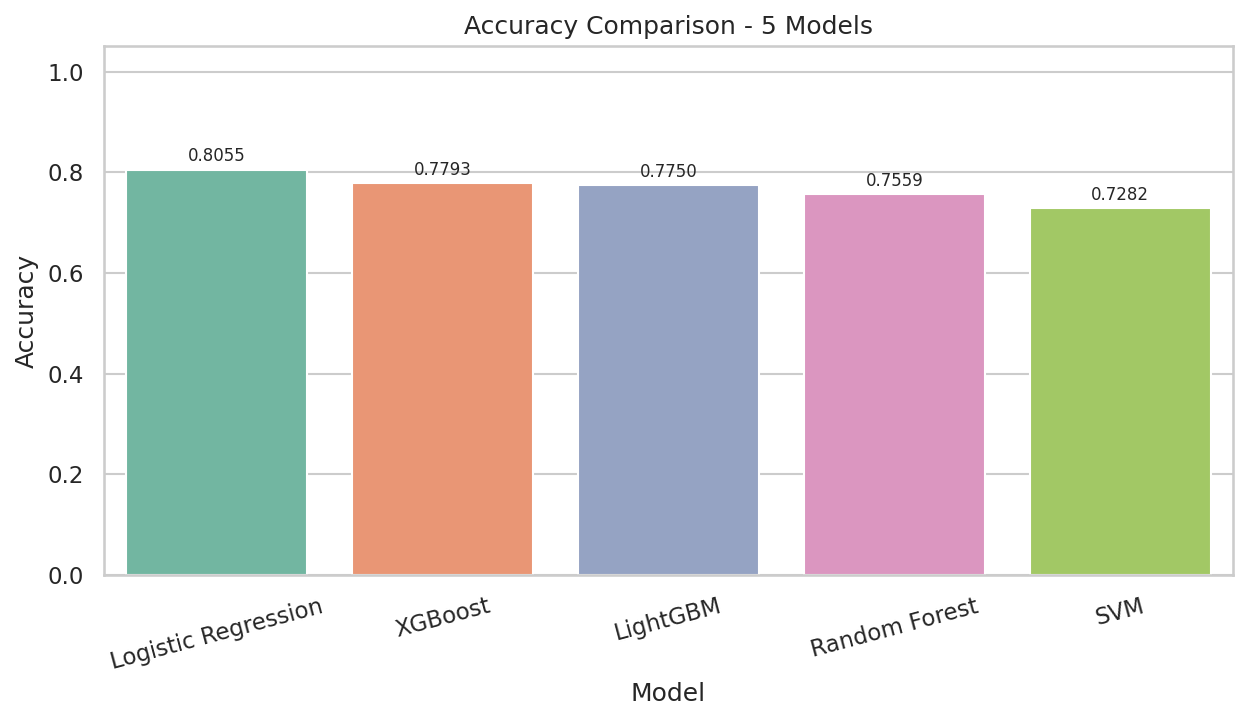

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '12_accuracy_comparison.png')
if os.path.exists(image_path):
    print('Displaying 12_accuracy_comparison.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 20_custom_3_panel_figure.png (Accuracy for Best Model):


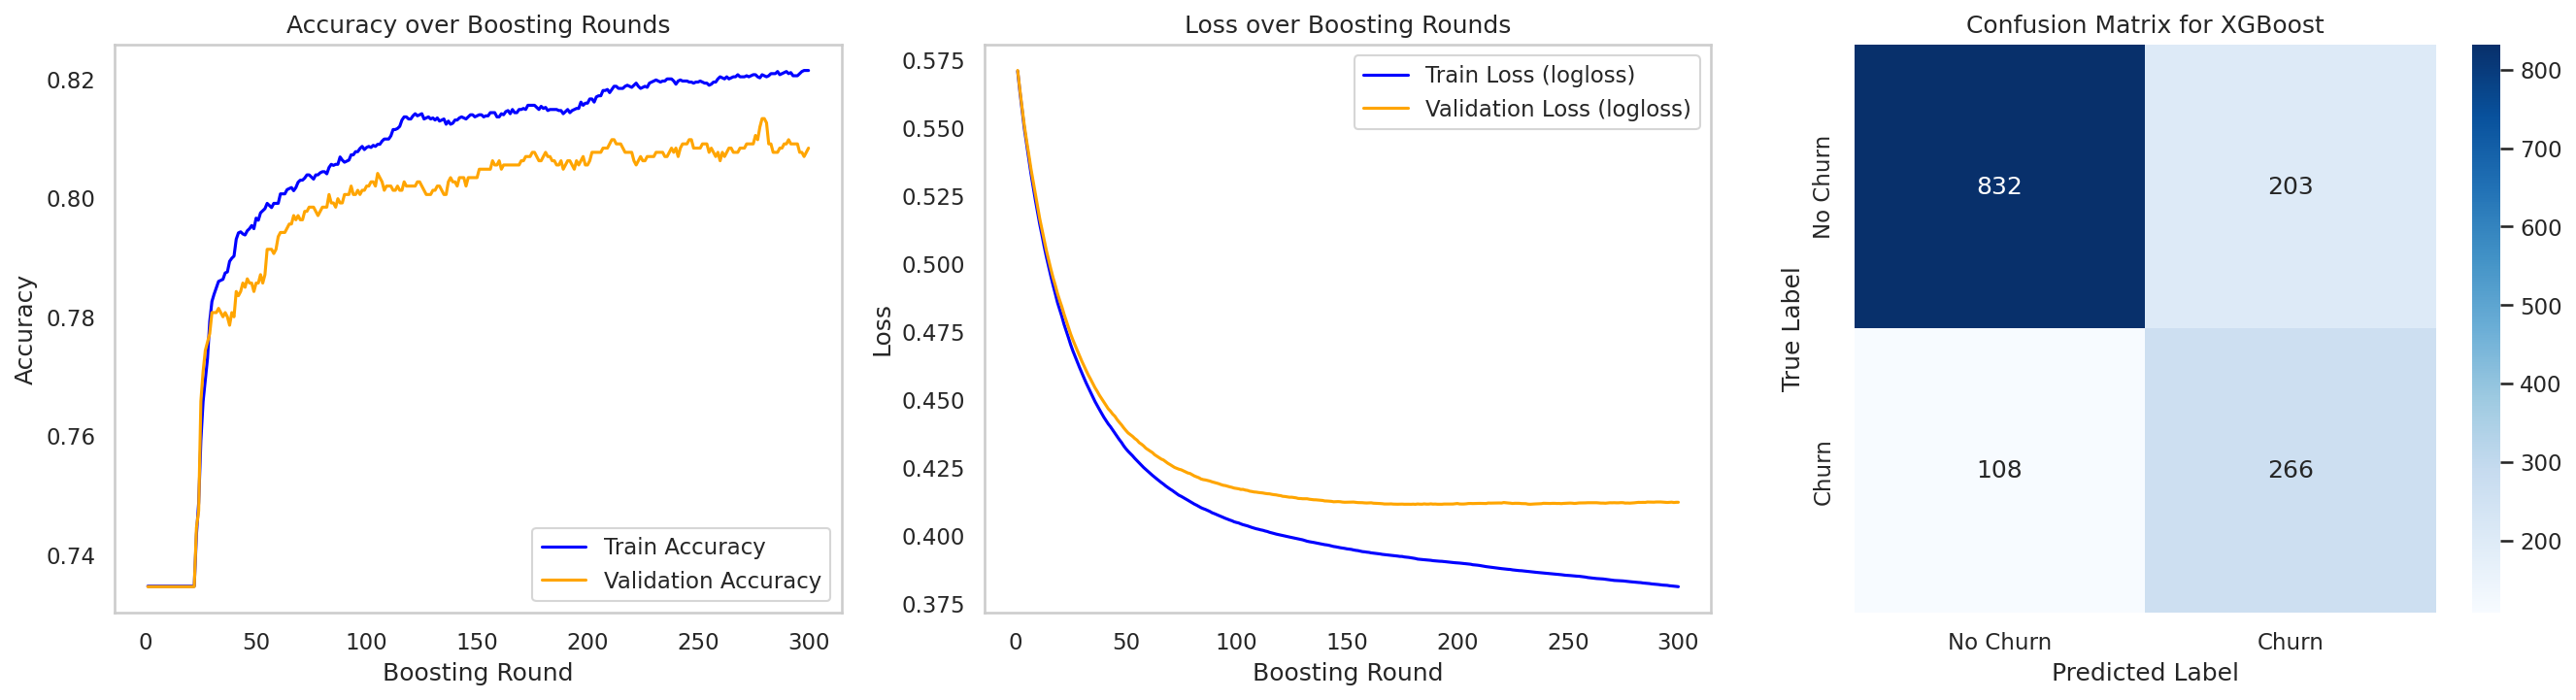

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '20_custom_3_panel_figure.png')
if os.path.exists(image_path):
    print('Displaying 20_custom_3_panel_figure.png (Accuracy for Best Model):')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

In [ ]:
import shutil
from google.colab import files
import os

# Define the directory to zip
plots_directory = PLOTS_DIR # PLOTS_DIR is defined in the notebook context

# Define the output zip file name
zip_file_name = 'churn_prediction_plots'

# Create a zip archive of the plots directory
shutil.make_archive(zip_file_name, 'zip', plots_directory)

# Download the created zip file
files.download(f'{zip_file_name}.zip')

print(f'Successfully created and downloaded {zip_file_name}.zip containing all plots.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully created and downloaded churn_prediction_plots.zip containing all plots.


Displaying 01_churn_distribution.png:


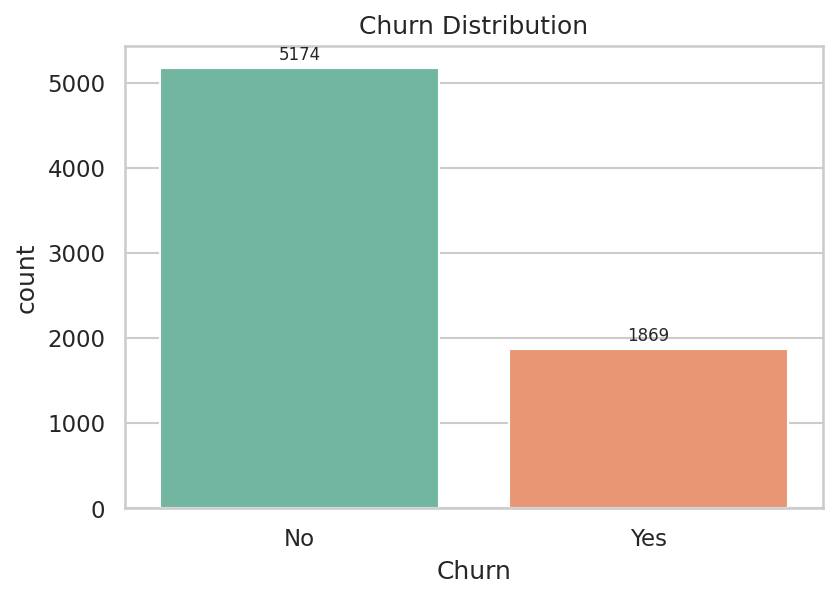

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '01_churn_distribution.png')
if os.path.exists(image_path):
    print('Displaying 01_churn_distribution.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 02_contract_vs_churn.png:


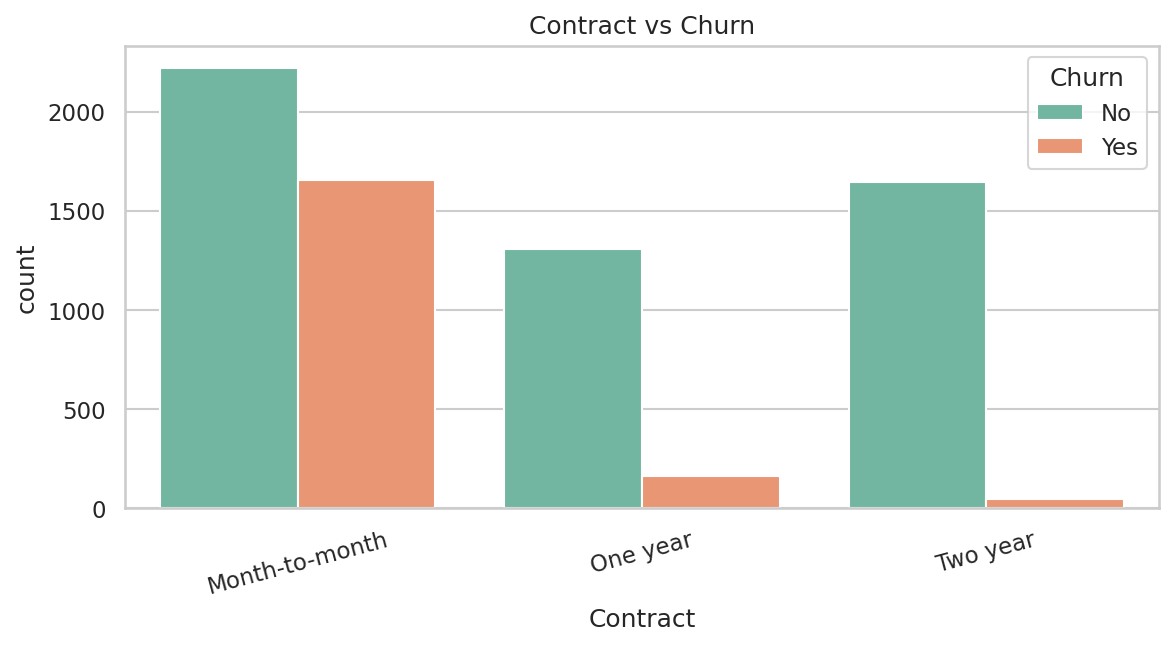

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '02_contract_vs_churn.png')
if os.path.exists(image_path):
    print('Displaying 02_contract_vs_churn.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 03_internetservice_vs_churn.png:


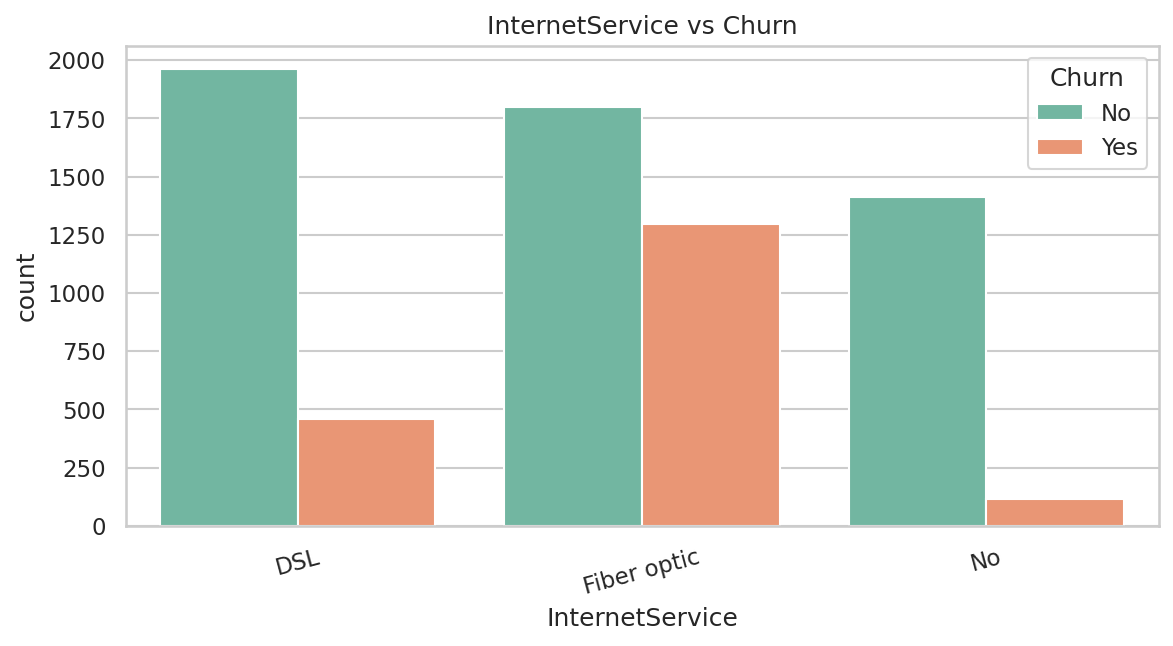

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '03_internetservice_vs_churn.png')
if os.path.exists(image_path):
    print('Displaying 03_internetservice_vs_churn.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 04a_tenure_hist_vs_churn.png:


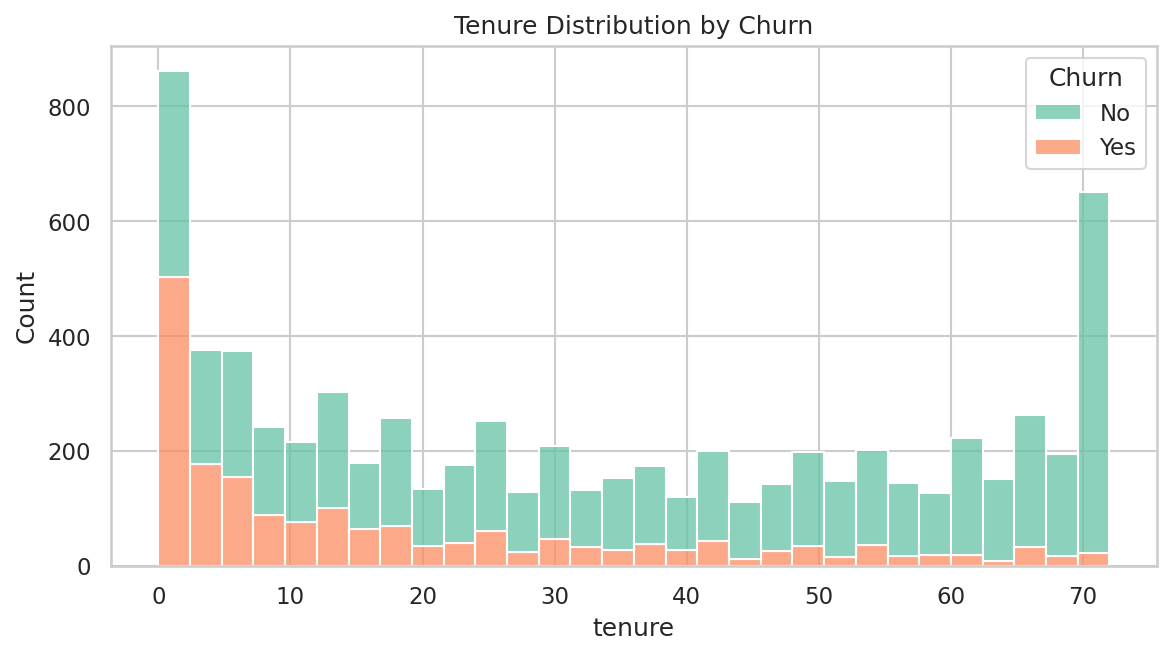

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '04a_tenure_hist_vs_churn.png')
if os.path.exists(image_path):
    print('Displaying 04a_tenure_hist_vs_churn.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 04b_tenure_box_vs_churn.png:


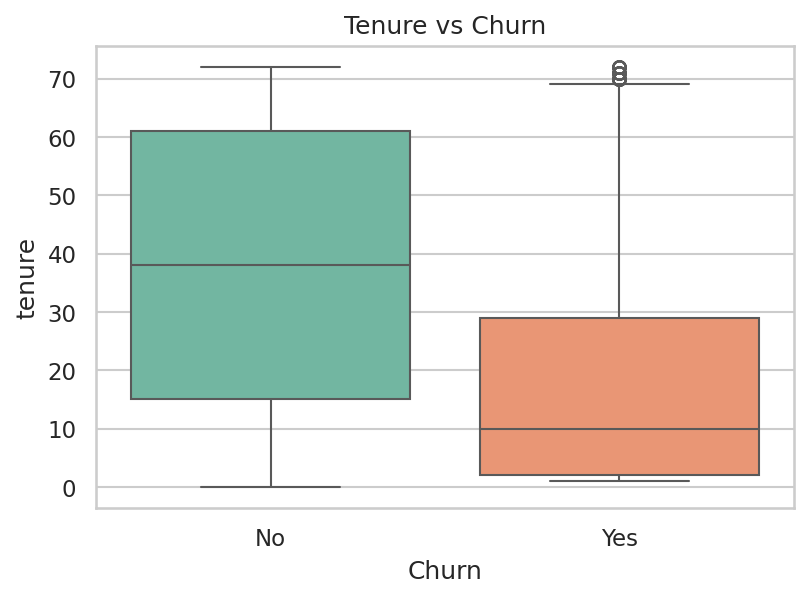

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '04b_tenure_box_vs_churn.png')
if os.path.exists(image_path):
    print('Displaying 04b_tenure_box_vs_churn.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 05a_monthlycharges_kde_vs_churn.png:


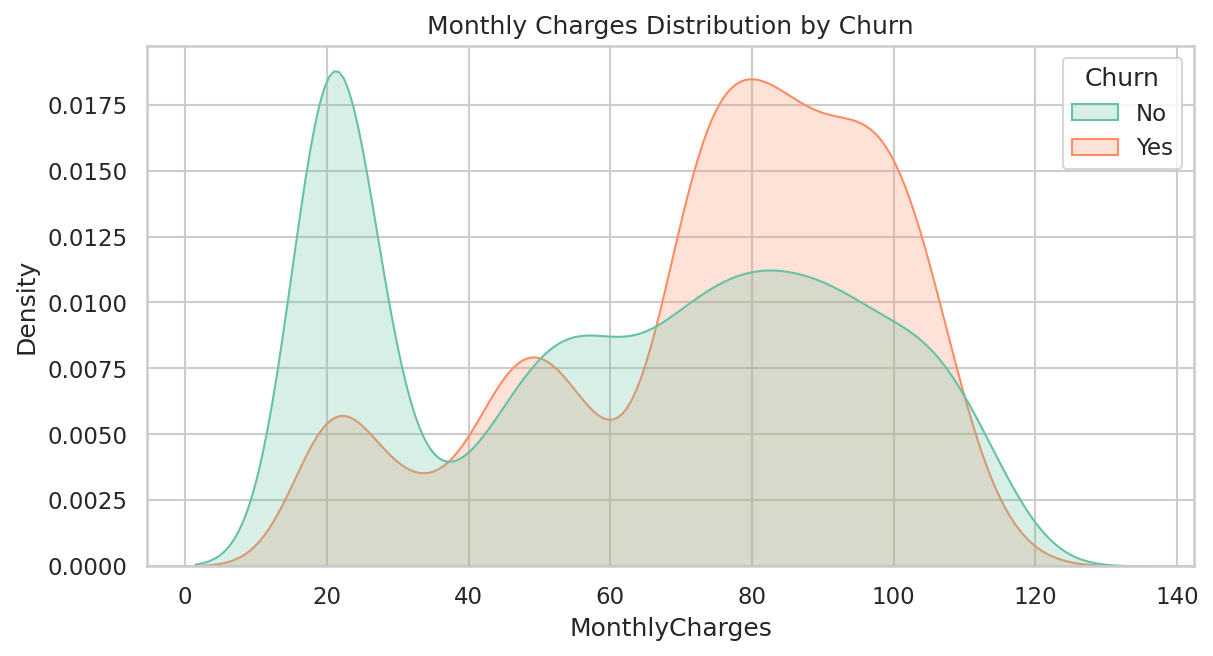

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '05a_monthlycharges_kde_vs_churn.png')
if os.path.exists(image_path):
    print('Displaying 05a_monthlycharges_kde_vs_churn.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 05b_monthlycharges_box_vs_churn.png:


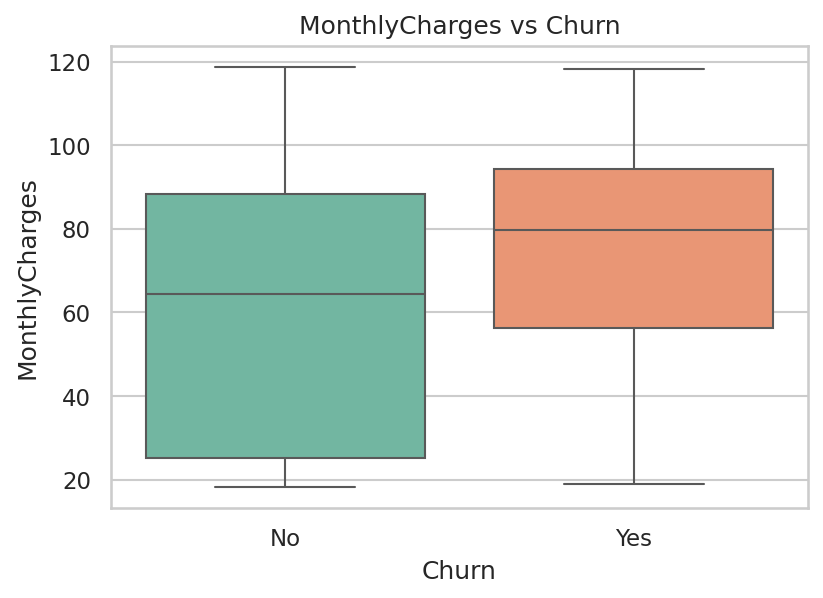

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '05b_monthlycharges_box_vs_churn.png')
if os.path.exists(image_path):
    print('Displaying 05b_monthlycharges_box_vs_churn.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 06_paymentmethod_vs_churn.png:


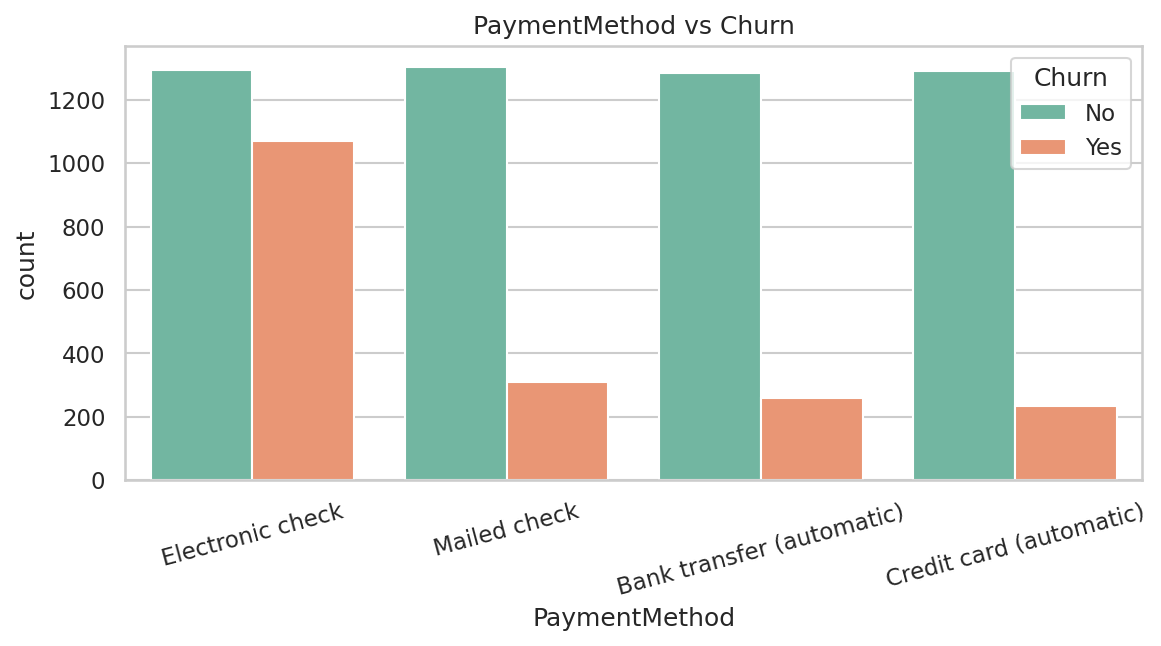

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '06_paymentmethod_vs_churn.png')
if os.path.exists(image_path):
    print('Displaying 06_paymentmethod_vs_churn.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 07a_correlation_heatmap_numeric.png:


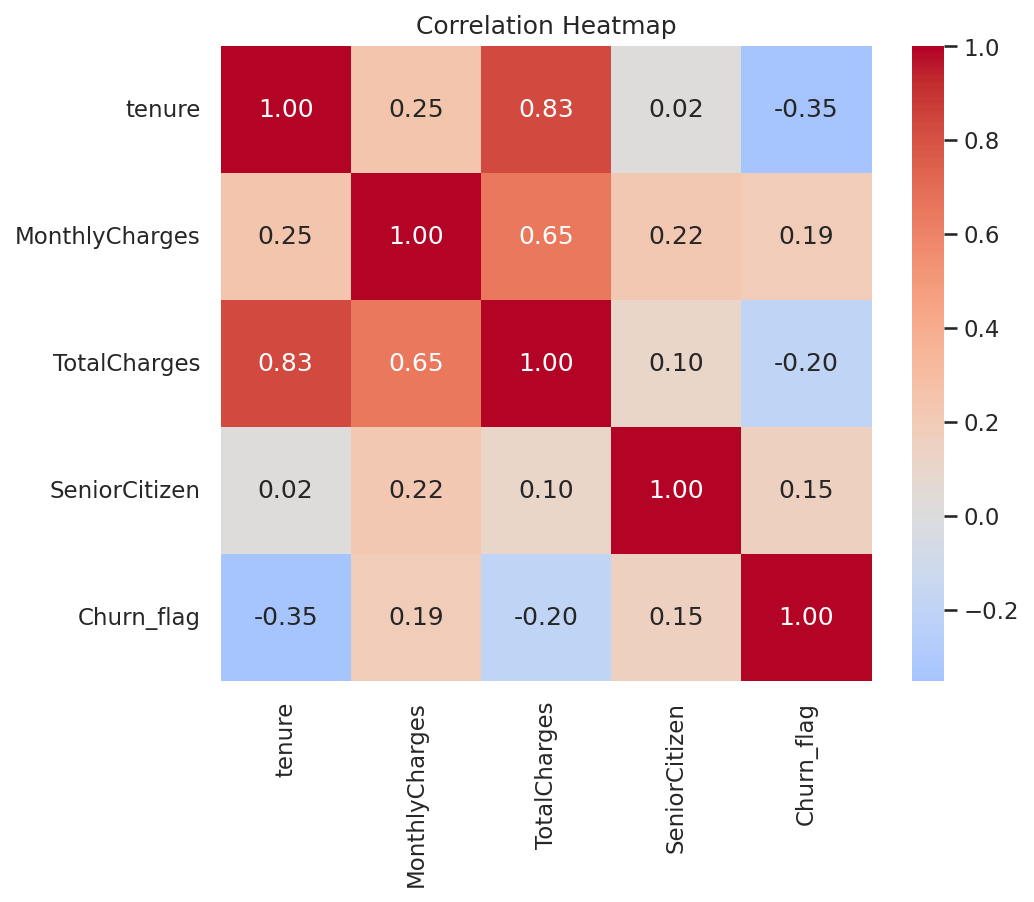

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '07a_correlation_heatmap_numeric.png')
if os.path.exists(image_path):
    print('Displaying 07a_correlation_heatmap_numeric.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 07b_correlation_heatmap_full.png:


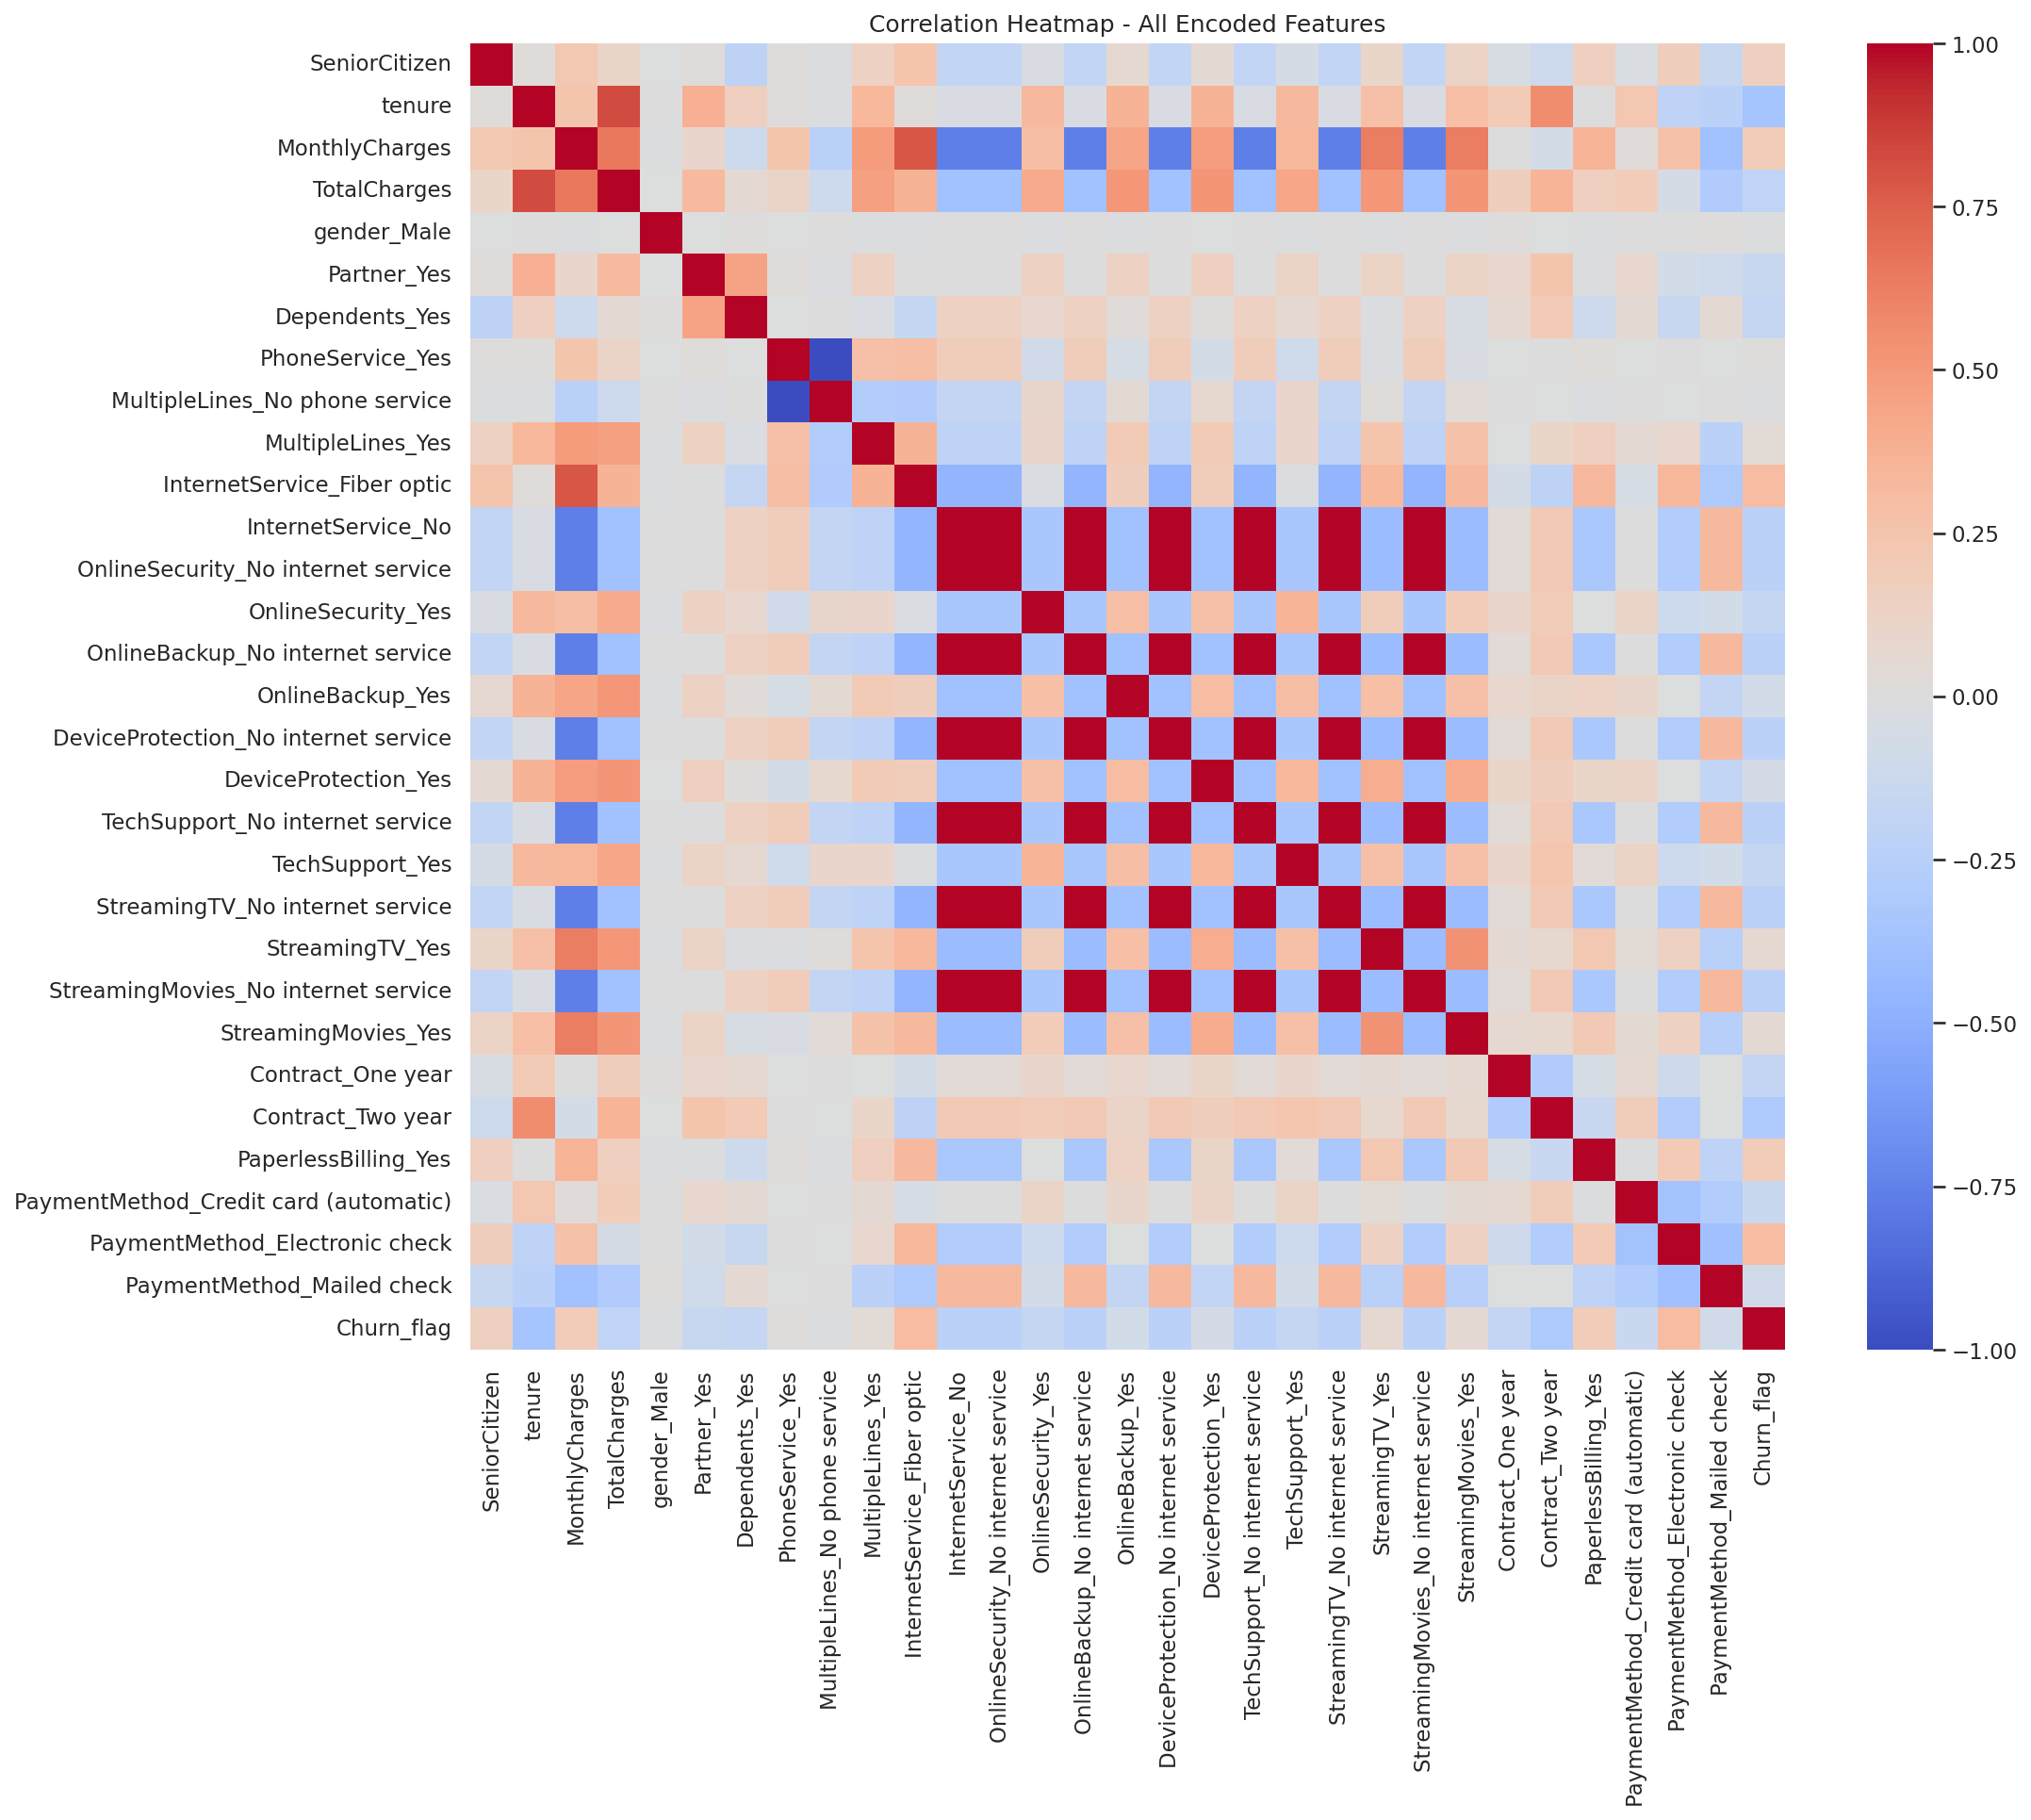

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '07b_correlation_heatmap_full.png')
if os.path.exists(image_path):
    print('Displaying 07b_correlation_heatmap_full.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 08_class_imbalance.png:


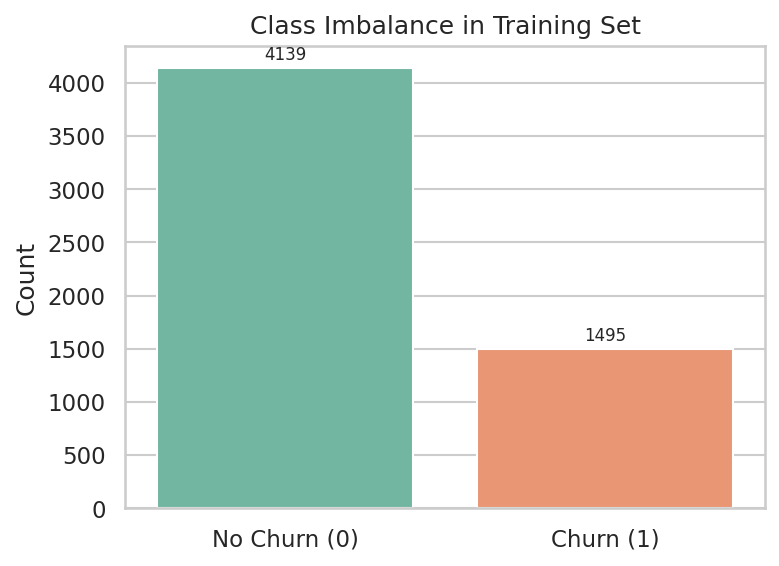

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '08_class_imbalance.png')
if os.path.exists(image_path):
    print('Displaying 08_class_imbalance.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 09a_confusion_matrices_all_models.png:


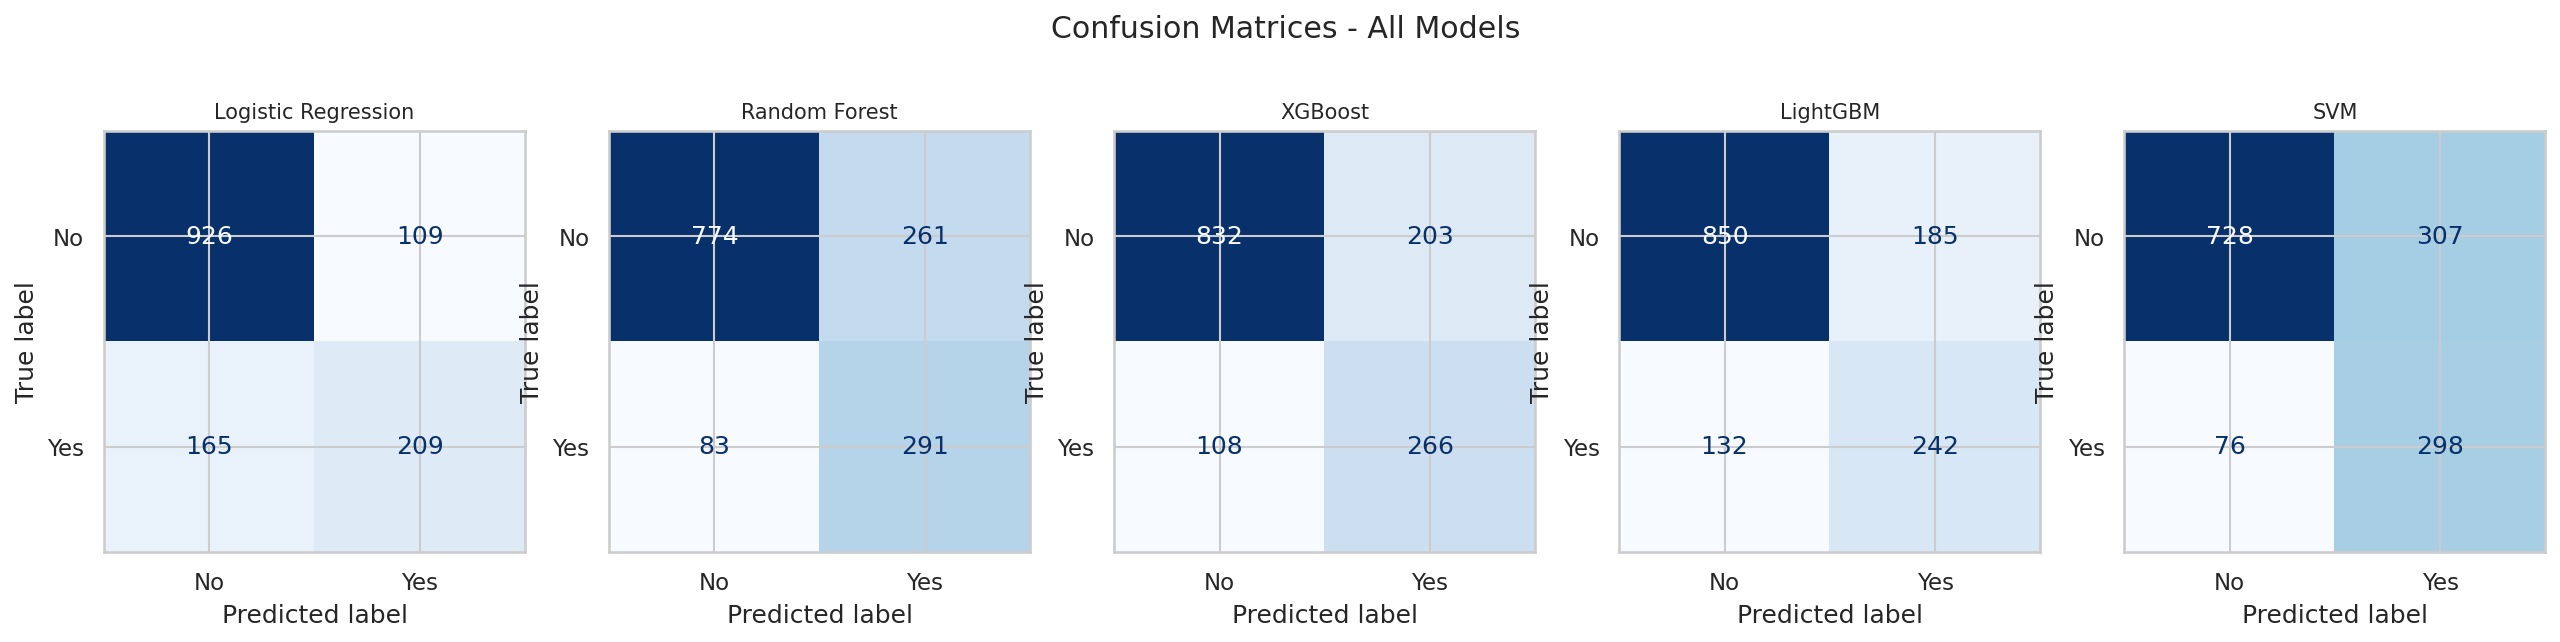

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '09a_confusion_matrices_all_models.png')
if os.path.exists(image_path):
    print('Displaying 09a_confusion_matrices_all_models.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 09b_confusion_matrix_best_model.png:


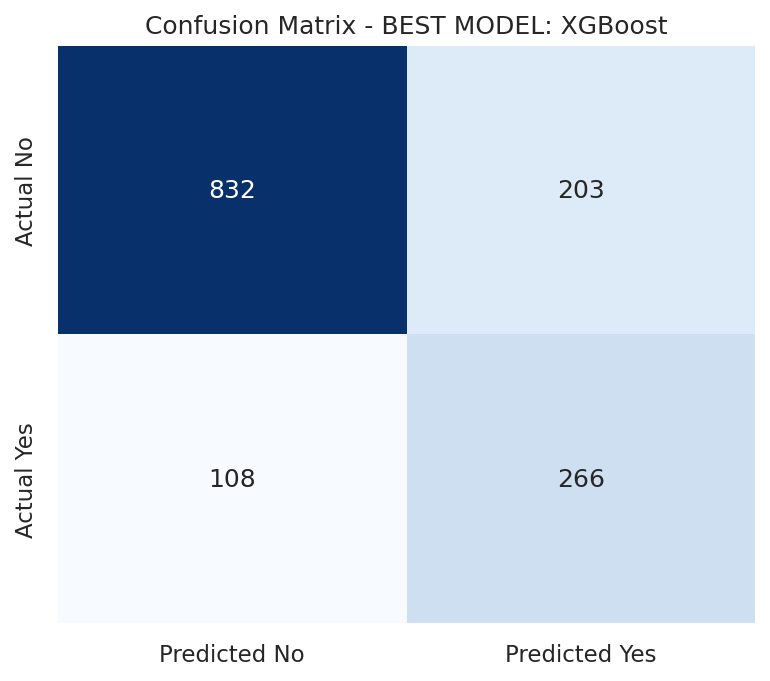

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '09b_confusion_matrix_best_model.png')
if os.path.exists(image_path):
    print('Displaying 09b_confusion_matrix_best_model.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 10_roc_curves.png:


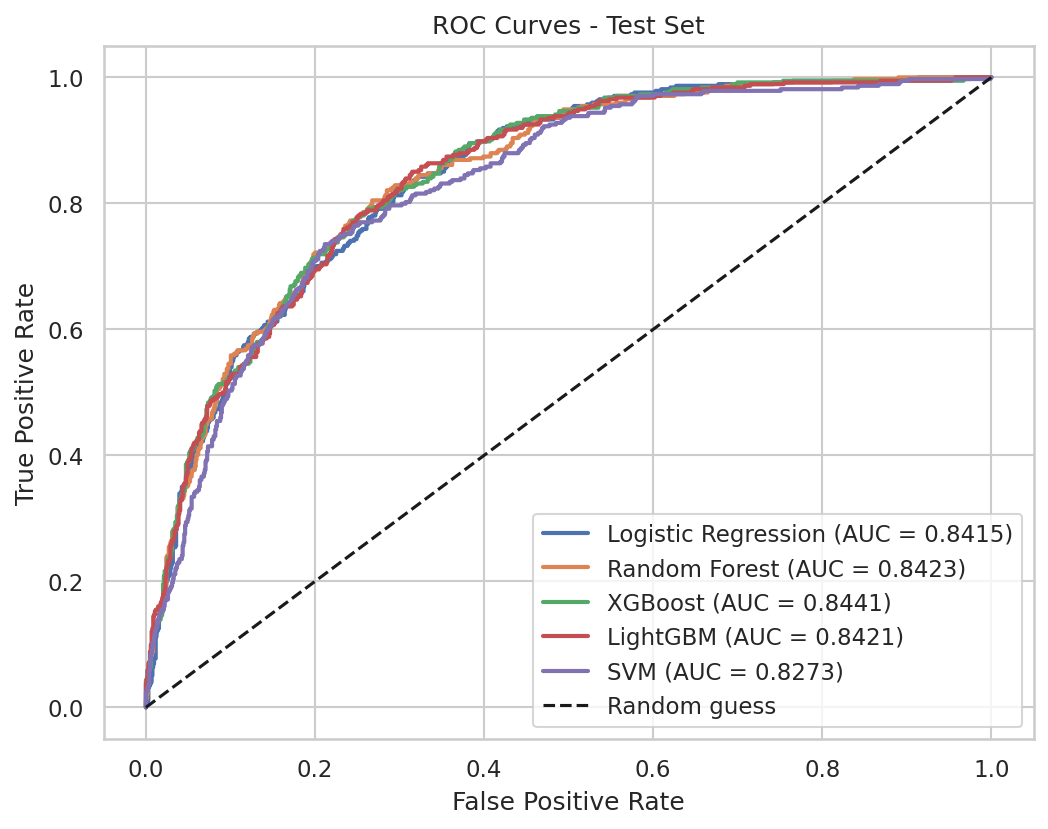

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '10_roc_curves.png')
if os.path.exists(image_path):
    print('Displaying 10_roc_curves.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 11_precision_recall_curves.png:


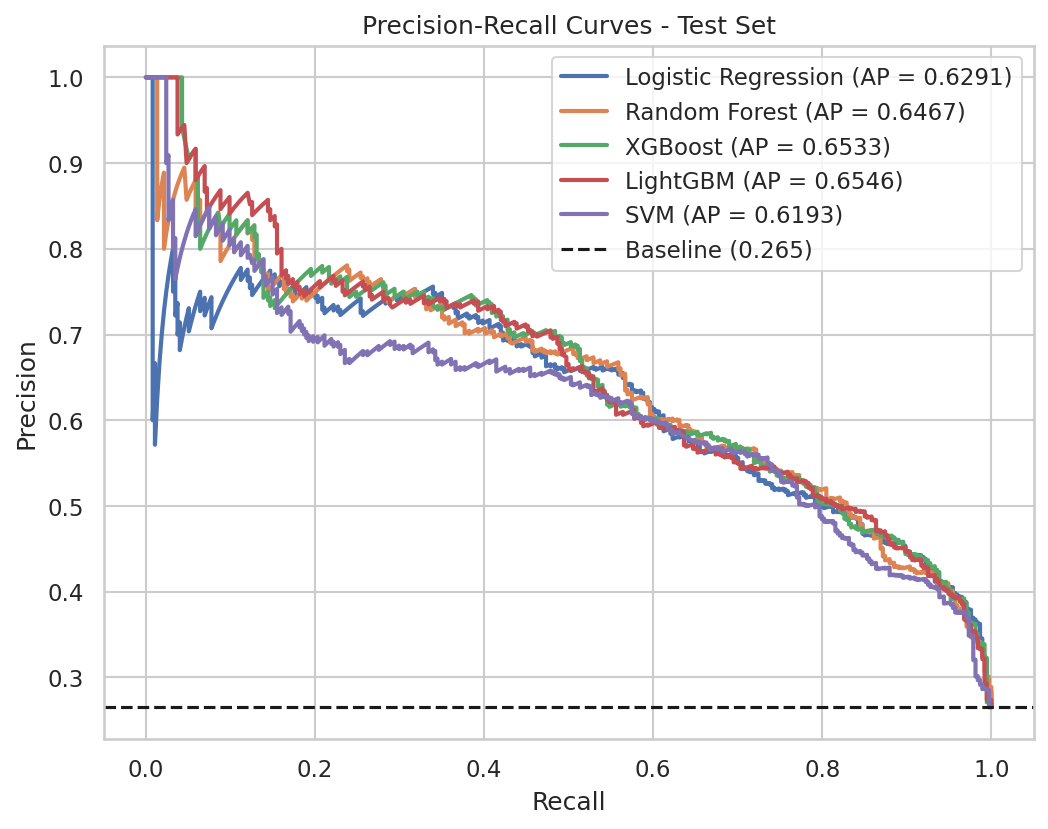

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '11_precision_recall_curves.png')
if os.path.exists(image_path):
    print('Displaying 11_precision_recall_curves.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 12_accuracy_comparison.png:


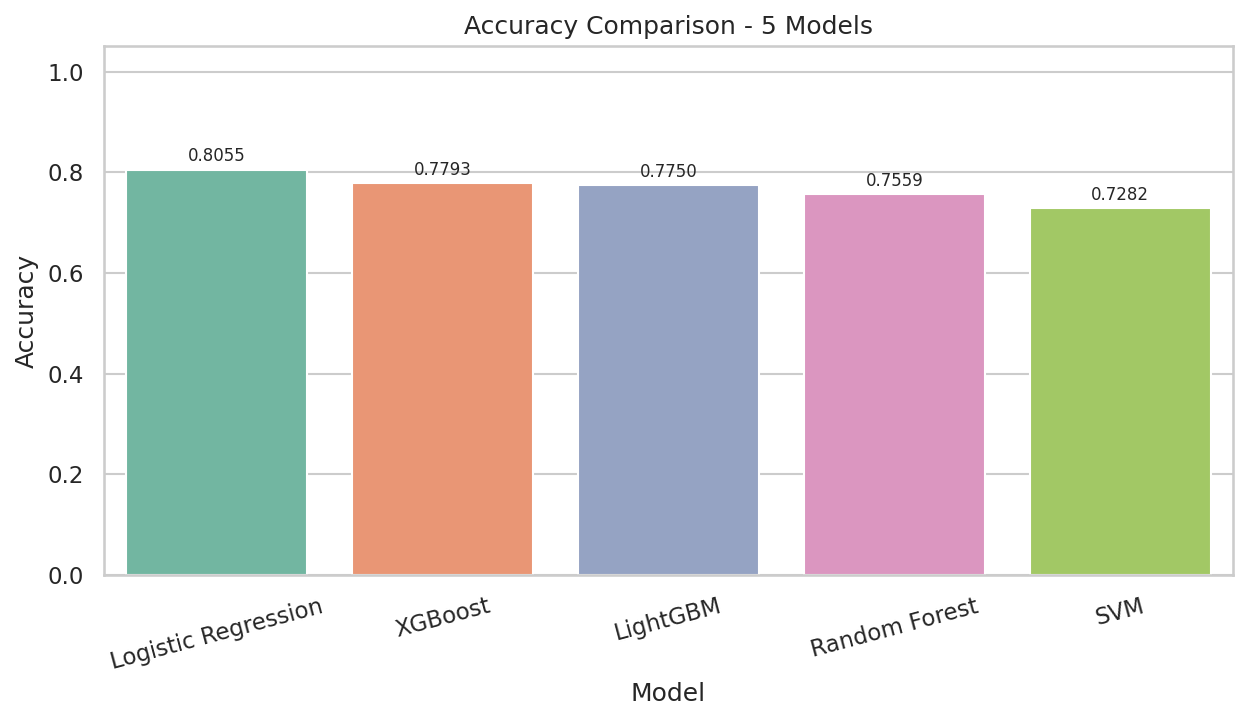

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '12_accuracy_comparison.png')
if os.path.exists(image_path):
    print('Displaying 12_accuracy_comparison.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 13_f1_score_comparison.png:


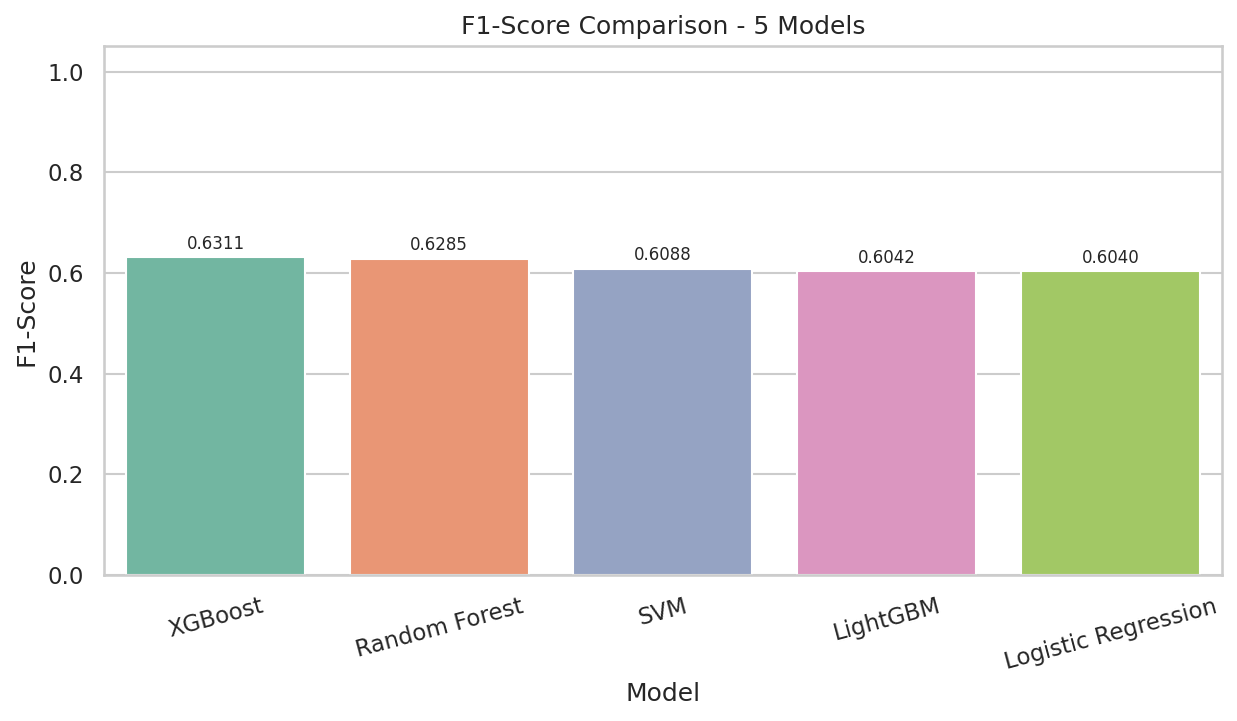

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '13_f1_score_comparison.png')
if os.path.exists(image_path):
    print('Displaying 13_f1_score_comparison.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 14_log_loss_comparison.png:


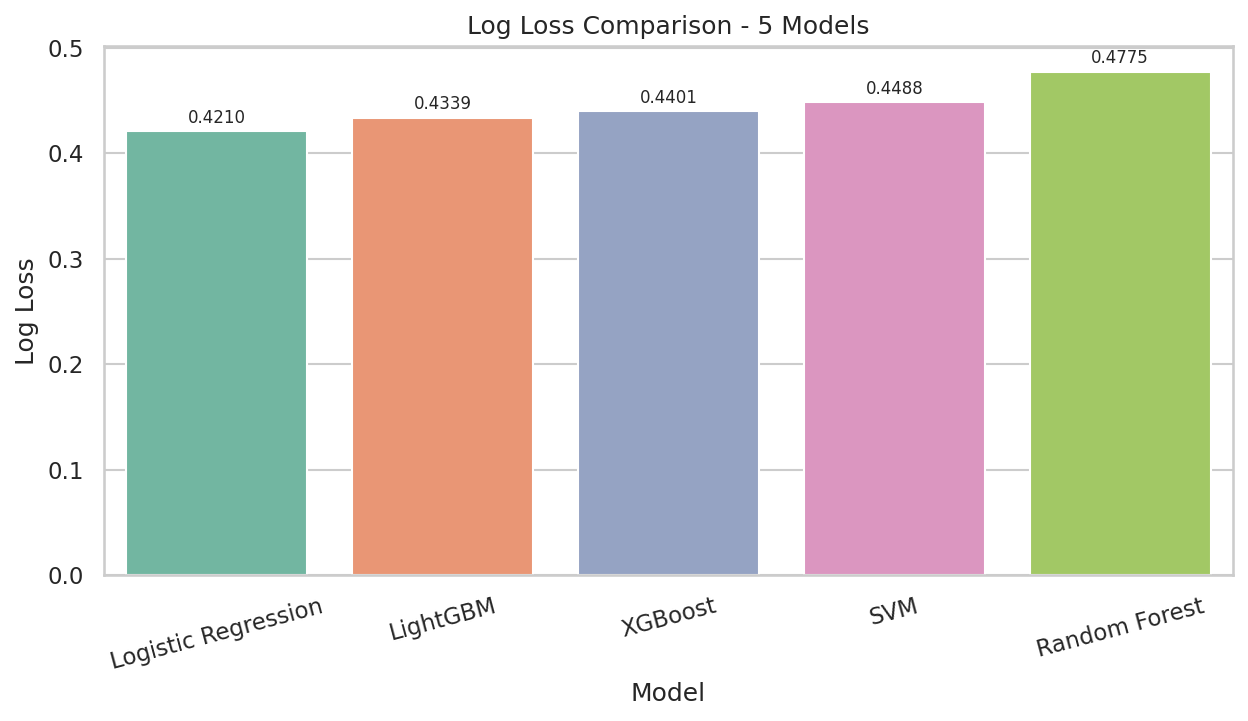

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '14_log_loss_comparison.png')
if os.path.exists(image_path):
    print('Displaying 14_log_loss_comparison.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 15_roc_auc_comparison.png:


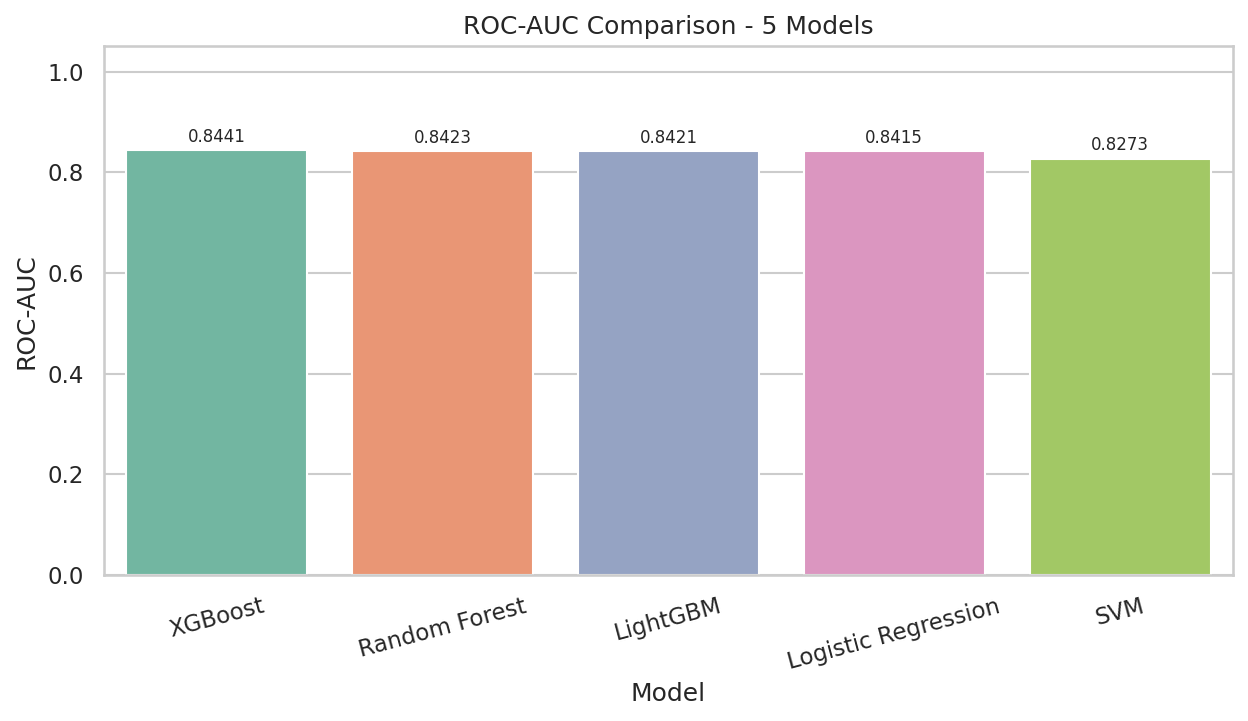

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '15_roc_auc_comparison.png')
if os.path.exists(image_path):
    print('Displaying 15_roc_auc_comparison.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 16_overall_model_comparison.png:


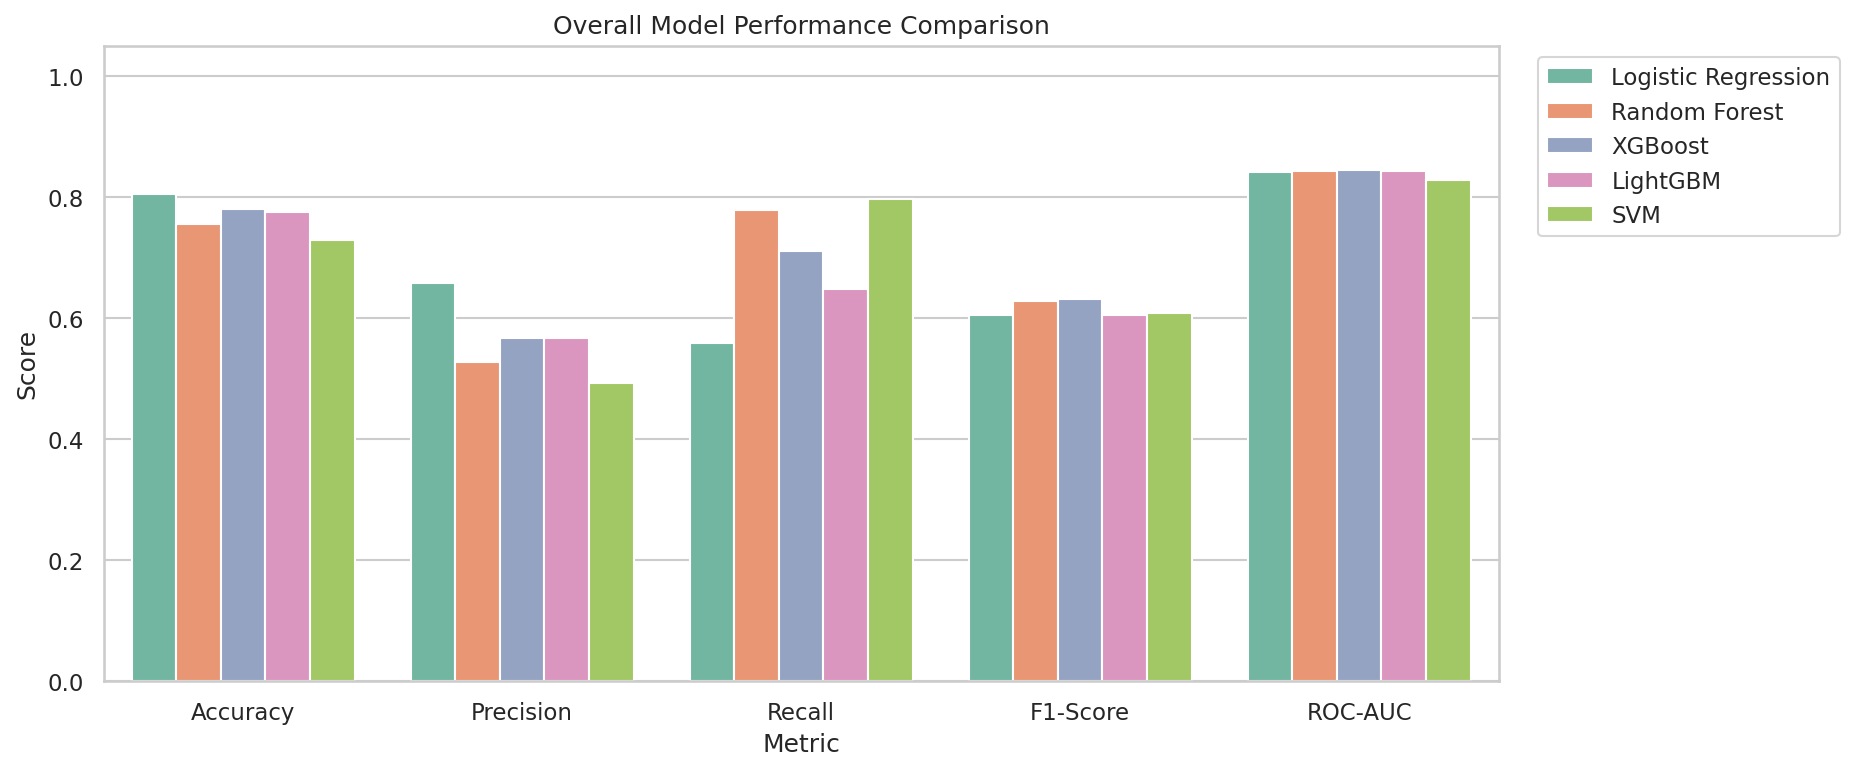

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '16_overall_model_comparison.png')
if os.path.exists(image_path):
    print('Displaying 16_overall_model_comparison.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 17_metric_heatmap.png:


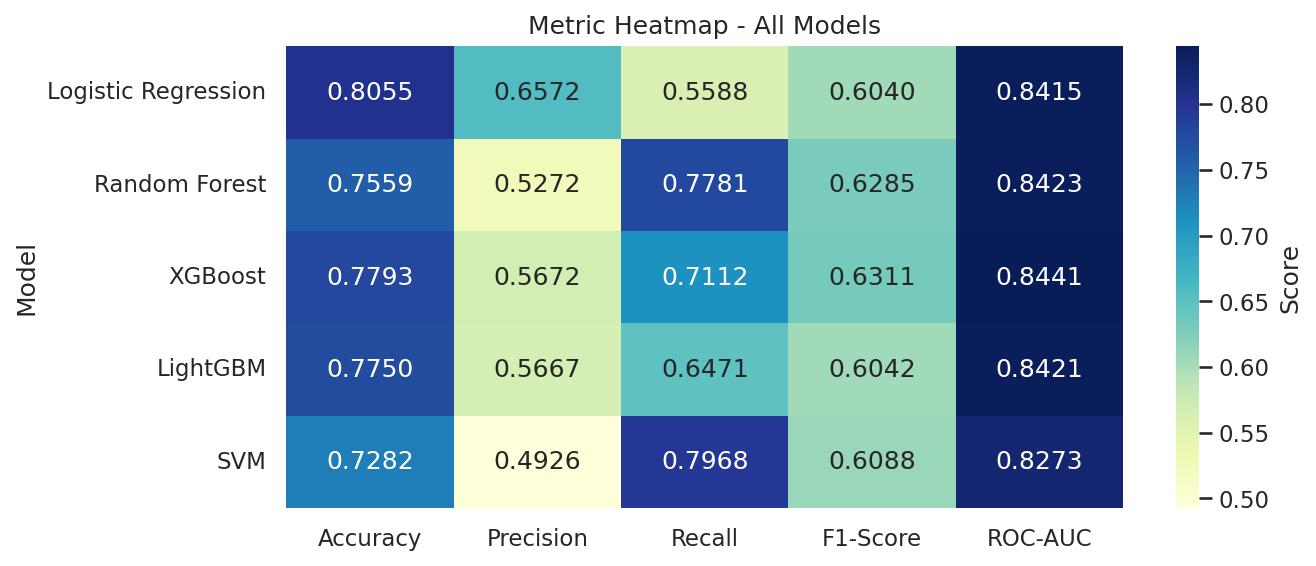

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '17_metric_heatmap.png')
if os.path.exists(image_path):
    print('Displaying 17_metric_heatmap.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 18_shap_summary_plot.png:


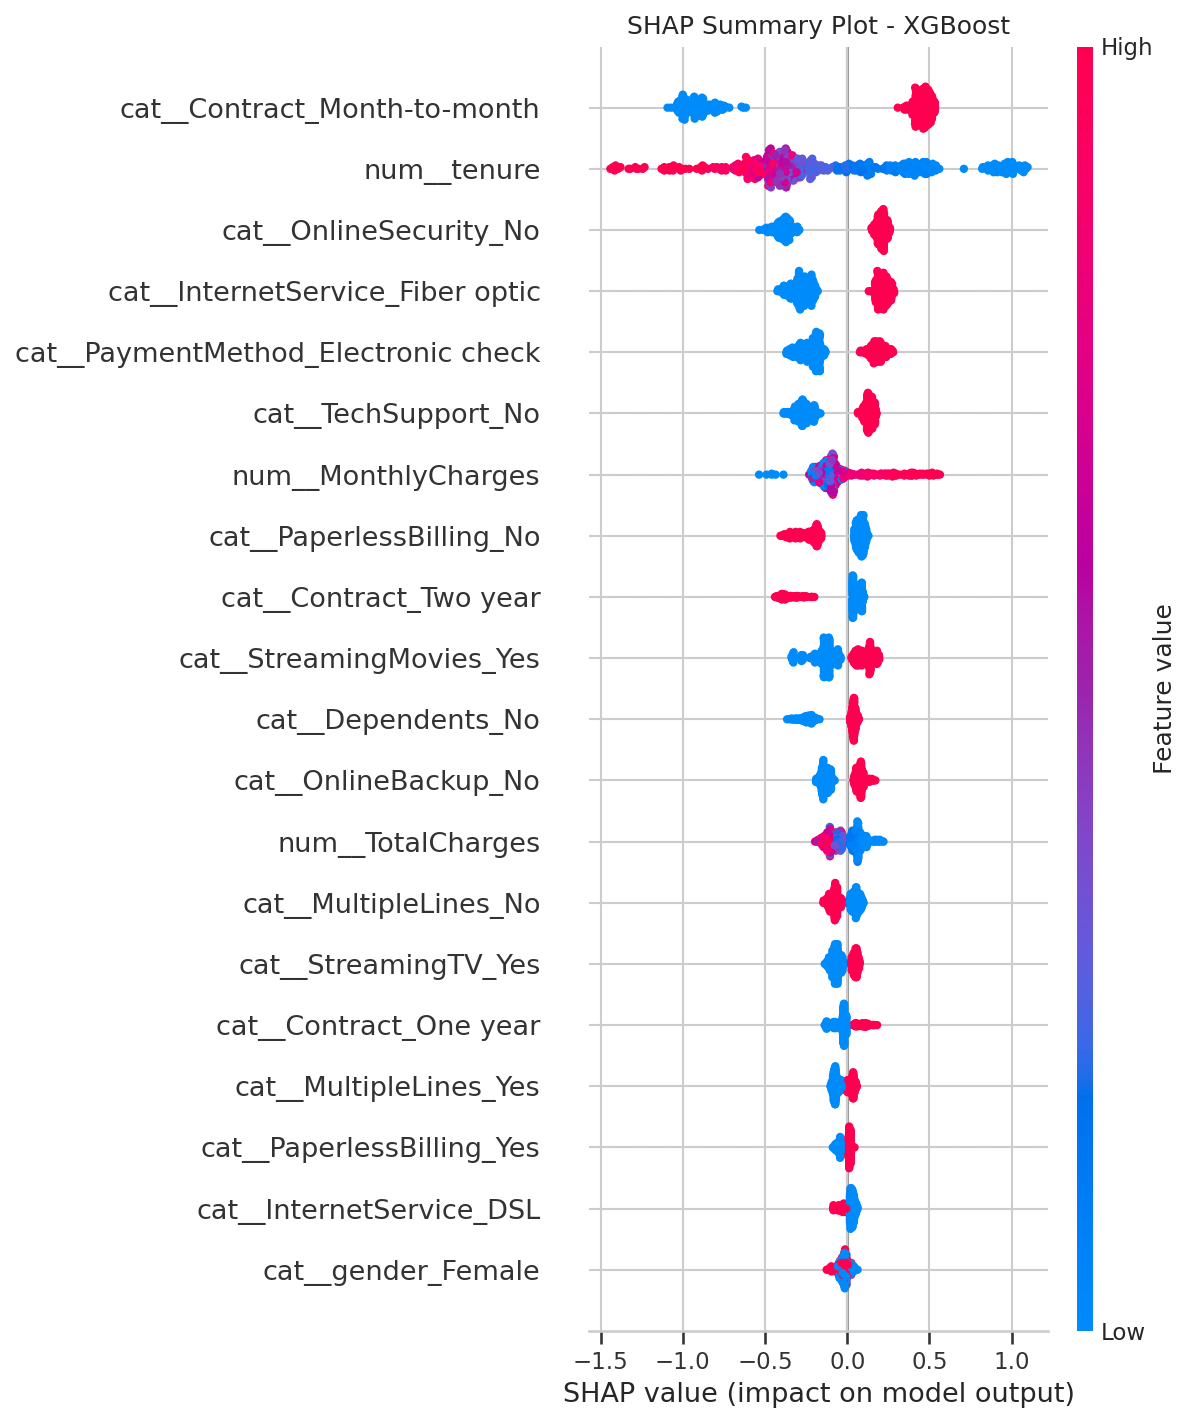

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '18_shap_summary_plot.png')
if os.path.exists(image_path):
    print('Displaying 18_shap_summary_plot.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Displaying 19_shap_feature_importance.png:


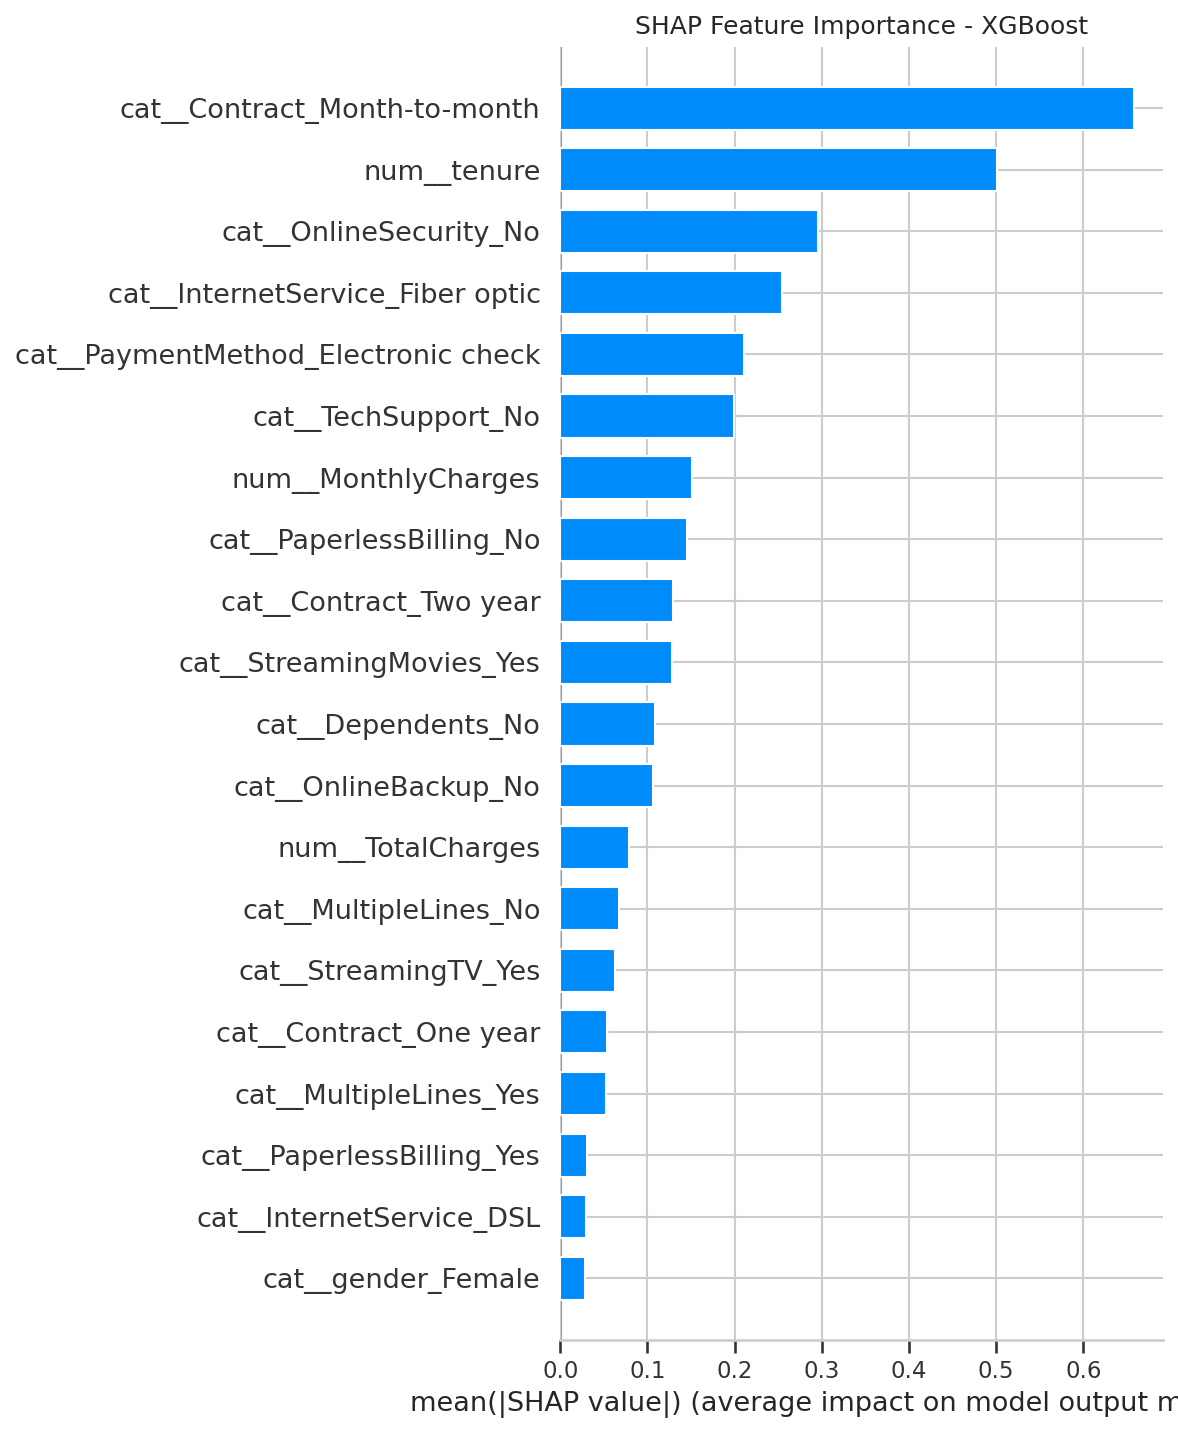

In [ ]:
from IPython.display import Image, display
import os

image_path = os.path.join(PLOTS_DIR, '19_shap_feature_importance.png')
if os.path.exists(image_path):
    print('Displaying 19_shap_feature_importance.png:')
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

Generating 'Accuracy Comparison - 5 Models' graph...
   [plot saved] plots/12_accuracy_comparison.png

Accuracy ranking:
              Model  Accuracy
Logistic Regression    0.8055
            XGBoost    0.7793
           LightGBM    0.7750
      Random Forest    0.7559
                SVM    0.7282
Displaying the generated 12_accuracy_comparison.png:


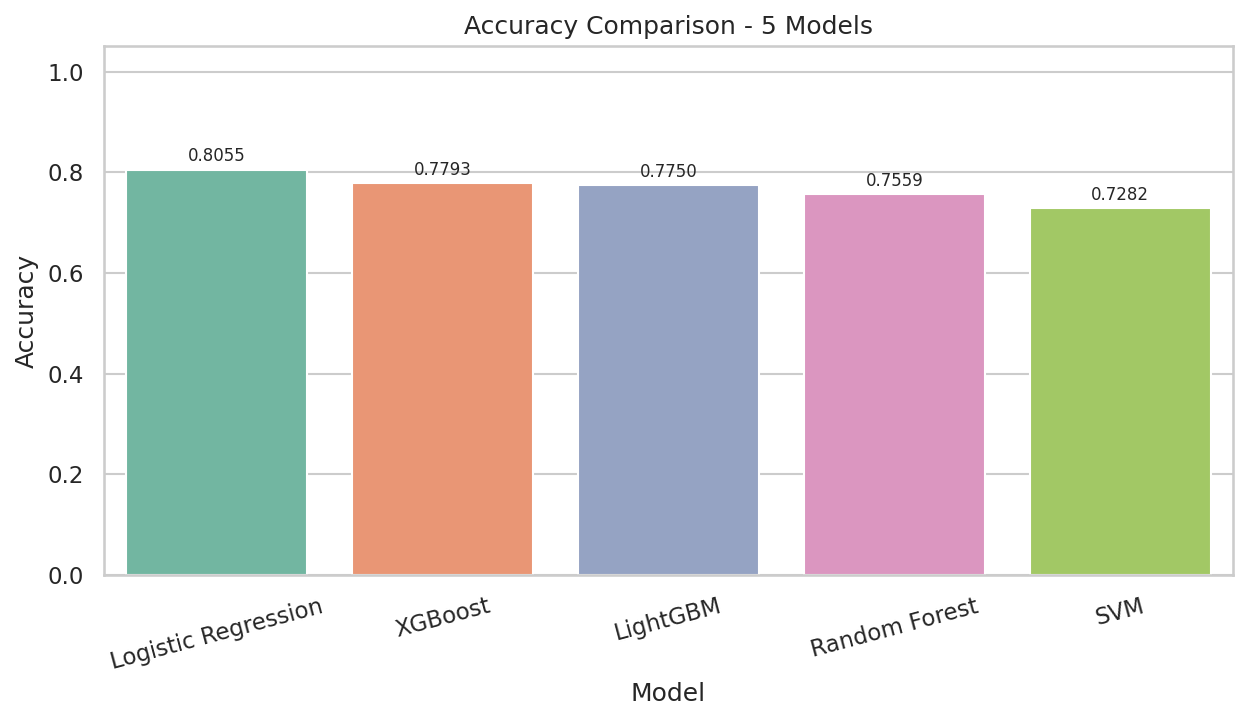

In [ ]:
print("Generating 'Accuracy Comparison - 5 Models' graph...")
# Accuracy
single_metric_chart(
    "Accuracy",
    "12_accuracy_comparison.png",
    "Accuracy Comparison - 5 Models",
    ylim=(0, 1.05)
)

# Display the newly generated plot (if it's saved correctly)
from IPython.display import Image, display
import os

image_path_to_display = os.path.join(PLOTS_DIR, '12_accuracy_comparison.png')
if os.path.exists(image_path_to_display):
    print('Displaying the generated 12_accuracy_comparison.png:')
    display(Image(filename=image_path_to_display))
else:
    print(f"Generated image not found at {image_path_to_display}")

In [ ]:
import os
from google.colab import files

for filename in os.listdir(PLOTS_DIR):
    file_path = os.path.join(PLOTS_DIR, filename)
    if os.path.isfile(file_path):
        print(f"Downloading {filename}...")
        files.download(file_path)
print("All plot files downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All plot files downloaded.


In [ ]:
churn